In [5]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
# from utils import ml_pipeline as ml
import spacy
from collections import Counter
import math
# from langdetect import detect
import nltk
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords
import os
import joblib
from sklearn.preprocessing import StandardScaler
# from utils import ml_pipeline as ml
# import shap
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import transforms
import typing
# from utils import plotting


### Preprocessing

In [2]:
drop_new = ['Segment', 'Emoji', 'netspeak', 'sexual', 'swear', 'conflict', 'politic', 'ethnicity', 'tech', 'relig', 'illness', 'wellness', 'mental', 'substances', 'death', 'fatigue', 'reward']

In [3]:
p = './FEATURES/stt_whisper/ad check for issues/'
df_ad_features = ml.text_analysis_features(p)
df_ad_features

Processing 87 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,024,12.25,1185.50,4.63,0.42,0.01
1,025,12.08,1359.94,5.04,0.50,0.00
2,027,10.12,1977.84,4.23,0.40,0.00
3,028,9.07,1579.18,4.26,0.40,0.02
4,031,11.46,1206.33,4.27,0.38,0.01
...,...,...,...,...,...,...
82,247,10.11,2262.21,4.55,0.44,0.00
83,248,9.35,2903.39,4.09,0.38,0.00
84,249,10.28,1110.66,3.83,0.46,0.00
85,250,11.55,1308.07,4.77,0.43,0.01


In [6]:
p = './FEATURES/stt_whisper/cn check for issues/'
df_cn_features = ml.text_analysis_features(p)
df_cn_features

Processing 79 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,002,11.31,1832.80,5.07,0.41,0.01
1,003,9.79,1983.02,4.22,0.44,0.00
2,005,10.43,2608.55,5.42,0.44,0.00
3,007,8.72,2641.25,4.54,0.41,0.00
4,008,10.87,1535.03,4.88,0.48,0.00
...,...,...,...,...,...,...
74,309,10.61,1377.11,4.46,0.38,0.00
75,310,11.03,1088.39,3.93,0.32,0.00
76,312,11.51,1109.04,4.00,0.37,0.00
77,315,10.54,1815.28,4.15,0.46,0.00


In [7]:
PATH = './FEATURES/liwc/new-LIWC-checked/'
df_ad = pd.read_csv(PATH + 'LIWC-22 Results - ad check for issues - LIWC Analysis.csv')
df_ad = df_ad.drop(columns=drop_new)
df_ad = df_ad.iloc[:, :-7]
df_ad['Filename'] = df_ad['Filename'].str.extract(r'(\d{3})')
df_ad = df_ad.merge(df_ad_features, left_on='Filename', right_on='PID', how='left')
df_ad.drop(columns=['PID'], inplace=True)
df_ad.loc[:, 'label'] = 1

In [8]:
PATH = './FEATURES/liwc/new-LIWC-checked/'
df_cn = pd.read_csv(PATH + 'LIWC-22 Results - cn check for issues - LIWC Analysis.csv')
df_cn = df_cn.drop(columns=drop_new)
df_cn = df_cn.iloc[:, :-7]
df_cn['Filename'] = df_cn['Filename'].str.extract(r'(\d{3})')
df_cn = df_cn.merge(df_cn_features, left_on='Filename', right_on='PID', how='left')
df_cn.drop(columns=['PID'], inplace=True)
df_cn.loc[:, 'label'] = 0


In [9]:
df_all = pd.concat([df_cn, df_ad], ignore_index=True)
def combine_features_liwc(row):
    return np.array(row[1:-1])

# Apply this function to each row
df_all['data'] = df_all.apply(combine_features_liwc, axis=1)
df_all = df_all.rename(columns={'Filename': 'pid'})
df_all = df_all[['pid', 'label', 'data']]

In [10]:
df_all.head()

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."


In [11]:
df_all.data[0].shape    

(100,)

In [13]:
PATH_SAVE = './FEATURES/dfs/'
df_all.to_pickle(PATH_SAVE + 'liwc22-size100.pkl')

In [14]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    liwc_train = pickle.load(f)
liwc_train.head()

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."


In [15]:
liwc_train.data[0].shape    

(100,)

### 10f CV

In [16]:
X = liwc_train['data']
y = liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

In [17]:
# NOTE: changed crossvalidation() to save in new folder
models = ml.create_models()
param_grids = ml.create_param_grids()

# model selection and crossvalidation
results = []
for name, model in models.items():
    result = ml.crossvalidation_UPD(name, model, param_grids[name], X_scaled_train, y, feature_set = 'w-liwc-size100')
    results.append(result)

df_eval_cv = pd.DataFrame(results)
df_eval_cv

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits


/Users/mr3418/opt/anaconda3/envs/phd_analysis_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/mr3418/opt/anaconda3/envs/phd_analysis_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/mr3418/opt/anaconda3/envs/phd_analysis_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/mr3418/opt/anaconda3/envs/phd_analysis_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/mr3418/op

Fitting 10 folds for each of 50 candidates, totalling 500 fits


,Model,Sensitivity,Specificity,Roc_auc,Accuracy
0,lr,70.4 (10.0),77.3 (9.2),78.6 (6.0),73.6 (6.5)
1,svm,75.0 (14.5),69.5 (14.3),78.1 (5.2),72.2 (8.6)
2,rf,78.8 (16.7),72.1 (13.4),83.5 (8.9),75.3 (9.4)
3,nn,69.4 (18.2),70.7 (17.2),73.4 (12.9),69.9 (7.9)
4,xgboost,79.4 (13.8),76.6 (21.9),83.3 (10.9),78.3 (10.7)


In [18]:
PATH_SAVE_DF = "./evaluation-training-UPD/"
df_eval_cv.to_csv(PATH_SAVE_DF + "cv_liwc22-size100.csv", index=False)

### Test data

In [20]:
p = './FEATURES/stt_whisper/test/'
df_test_features = ml.text_analysis_features(p)
df_test_features['PID'] = df_test_features['PID'].str.extract(r't(\d+)')[0]
df_test_features['PID'] = 'adrsdt' + df_test_features['PID'] 
df_test_features.head()

Processing 71 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,adrsdt1,11.03,1072.90,4.29,0.38,0.02
1,adrsdt10,9.57,3193.10,5.61,0.30,0.00
2,adrsdt11,12.28,1331.74,4.65,0.41,0.00
3,adrsdt12,11.38,1334.97,4.91,0.41,0.00
4,adrsdt13,8.48,1907.11,3.90,0.41,0.00


In [21]:
df_task = pd.read_csv('./ADReSSo21-TEST/task1.csv')
# Create a mapping dictionary for 'Dx' to labels (0 or 1)
dx_label_mapping = df_task.set_index('ID')['Dx'].apply(lambda x: 0 if x == 'Control' else 1).to_dict()

In [22]:
PATH = './FEATURES/test-features/liwc/'
df_test = pd.read_csv(PATH + 'whisper-test-LIWC2022Dict.csv')
df_test = df_test.drop(columns=drop_new)
df_test = df_test.iloc[:, :-7]
df_test['Filename'] = df_test['Filename'].str.extract(r'_t(\d+)\.txt')
df_test['Filename'] = 'adrsdt' + df_test['Filename'] 
df_test

,Filename,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic,...,auditory,feeling,time,focuspast,focuspresent,focusfuture,Conversation,assent,nonflu,filler
0,adrsdt58,57,47.02,94.48,1.00,5.65,8.14,14.04,89.47,73.68,...,0.0,0.0,1.75,7.02,5.26,7.02,0.00,0.00,0.00,0.0
1,adrsdt64,57,62.72,70.59,14.46,74.93,5.70,15.79,92.98,77.19,...,0.0,0.0,0.00,0.00,12.28,7.02,5.26,5.26,0.00,0.0
2,adrsdt70,62,95.94,97.31,25.64,6.37,4.43,6.45,95.16,74.19,...,0.0,0.0,1.61,0.00,9.68,11.29,6.45,3.23,1.61,0.0
3,adrsdt71,156,1.00,99.00,1.31,49.66,19.50,13.46,97.44,89.74,...,0.0,0.0,0.64,0.00,12.18,6.41,0.64,0.64,0.00,0.0
4,adrsdt65,107,88.19,94.26,10.52,48.73,15.29,12.15,89.72,71.03,...,0.0,0.0,0.93,0.00,10.28,4.67,0.93,0.93,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,adrsdt68,113,86.90,79.24,53.37,20.23,12.56,15.93,85.84,68.14,...,0.0,0.0,0.00,1.77,10.62,0.88,1.77,1.77,0.00,0.0
67,adrsdt69,111,99.00,93.46,98.80,32.75,6.53,15.32,88.29,61.26,...,0.0,0.9,0.00,0.00,14.41,0.00,0.00,0.00,0.00,0.0
68,adrsdt55,248,74.04,86.10,6.29,25.43,9.92,15.32,84.68,67.34,...,0.4,0.0,0.00,0.00,10.89,0.81,0.81,0.81,0.00,0.0
69,adrsdt41,49,97.86,74.89,66.12,82.06,12.25,14.29,85.71,65.31,...,0.0,0.0,0.00,2.04,10.20,0.00,0.00,0.00,0.00,0.0


In [23]:
df_test = df_test.merge(df_test_features, left_on='Filename', right_on='PID', how='left')
df_test.drop(columns=['PID'], inplace=True)
df_test['label'] = df_test['Filename'].apply(lambda x: dx_label_mapping.get(x, None))

In [24]:
# change string
df_test = df_test.rename(columns={'Filename': 'pid'})
df_test['pid'] = df_test['pid'].str.extract('adrsdt(\d+)')[0]
def combine_features_liwc(row):
    return np.array(row[1:-1])

# Apply this function to each row
df_test['data'] = df_test.apply(combine_features_liwc, axis=1)
liwc_test_reduced = df_test[['pid', 'label', 'data']]
liwc_test_reduced.head()

,pid,label,data
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89...."
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9..."
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95..."
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97...."
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15..."


In [25]:
df_test.data[2].shape

(100,)

In [26]:
PATH_SAVE_TEST = './FEATURES/test-features/dfs/'
liwc_test_reduced.to_pickle(PATH_SAVE_TEST + 'liwc22-size100.pkl')

In [27]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    liwc_all_test = pickle.load(f)
liwc_all_test.head()

,pid,label,data
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89...."
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9..."
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95..."
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97...."
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15..."


In [28]:
X_test = liwc_all_test['data']
y_test = liwc_all_test['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc-size100')
best_hyperparams

{'Logistic Regression': LogisticRegression(C=0.14024971326600358, max_iter=10000, penalty='l1',
                    random_state=42, solver='liblinear'),
 'SVM': SVC(C=0.0024604229580184175, gamma=5.2471211886275886e-05, kernel='linear',
     probability=True, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=16, min_samples_leaf=3, min_samples_split=4,
                        n_estimators=50, random_state=42),
 'Neural Network': MLPClassifier(activation='logistic', alpha=0.00016676611460145473,
               batch_size=64, hidden_layer_sizes=(400,),
               learning_rate='adaptive',
               learning_rate_init=0.0018595691547710715, max_iter=10000,
               random_state=42, solver='sgd'),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7484098603570379, device=None,
               early_stopping_rounds=None, enable_categorical=

In [29]:
evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

{'Logistic Regression': ('74.9 (72.0 - 77.7)',
  '85.0 (80.7 - 89.3)',
  '87.0 (84.7 - 89.2)',
  '80.0 (77.5 - 82.5)'),
 'SVM': ('75.4 (69.7 - 81.1)',
  '82.5 (75.8 - 89.2)',
  '88.0 (87.1 - 88.9)',
  '79.0 (77.4 - 80.6)'),
 'Random Forest': ('69.4 (66.4 - 72.5)',
  '83.3 (78.0 - 88.7)',
  '85.7 (83.8 - 87.6)',
  '76.5 (74.4 - 78.6)'),
 'Neural Network': ('71.1 (65.3 - 77.0)',
  '71.1 (66.6 - 75.6)',
  '76.8 (73.9 - 79.8)',
  '71.1 (68.0 - 74.3)'),
 'XGBoost': ('74.3 (69.9 - 78.7)',
  '81.4 (77.8 - 85.0)',
  '86.2 (84.4 - 87.9)',
  '77.9 (75.8 - 80.0)')}

In [30]:
# # Save the dictionary as a pickle file
# name = 'liwc22-size100-probs'
# with open(f'./evaluation-test-UPD/{name}.pkl', 'wb') as f:
#     pickle.dump(probs, f)

In [12]:
with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

### SHAP

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
import os
import joblib
feature_abbr = 'w-liwc-size100'
model_abbr = 'RF'
filename = f"10fcv_{model_abbr}.pkl"
file_path = os.path.join("./hyperparam-tuning-UPD", feature_abbr, filename)
if os.path.exists(file_path):
    best_model = joblib.load(file_path)
best_model

/Users/marialima/Desktop/Analysis/ml-analysis-py12/lib/python3.12/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.2.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


ValueError: node array from the pickle has an incompatible dtype:
- expected: {'names': ['left_child', 'right_child', 'feature', 'threshold', 'impurity', 'n_node_samples', 'weighted_n_node_samples', 'missing_go_to_left'], 'formats': ['<i8', '<i8', '<i8', '<f8', '<f8', '<i8', '<f8', 'u1'], 'offsets': [0, 8, 16, 24, 32, 40, 48, 56], 'itemsize': 64}
- got     : [('left_child', '<i8'), ('right_child', '<i8'), ('feature', '<i8'), ('threshold', '<f8'), ('impurity', '<f8'), ('n_node_samples', '<i8'), ('weighted_n_node_samples', '<f8')]

In [6]:
# changes conversation to Linguistic Disfluency
liwc_feature_names = ['WordCount','Analytic','Clout','Authentic','Tone','WordsPerSentence',\
    'BigWords','Dic','Linguistic','function','pronoun','ppron','i','we','you','shehe','they','ipron',\
    'det','article','number','prep','auxverb','adverb','conj','negate','verb','adj',\
    'quantity','Drives','affiliation','achieve','power','Cognition','allnone','cogproc','insight',\
    'cause','discrep','tentat','certitude','differ','memory','Affect','tone_pos','tone_neg',\
    'emotion','emo_pos','emo_neg','emo_anx','emo_anger','emo_sad','Social',\
    'socbehav','prosocial','polite','moral','comm','socrefs','family','friend','female',\
    'male','Culture','Lifestyle','leisure','home','work','money',\
    'Physical','health','food',\
    'need','want','acquire','lack','fulfill','risk','curiosity','allure',\
    'Perception','attention','motion','space','visual','auditory','feeling','time','focuspast',\
    'focuspresent','focusfuture','Linguistic Disfluency','assent','nonflu','filler',\
    'Brunet', 'Honore', 'CTTR', 'PIDensity', 'Duplic']
liwc_feature_names = [word.capitalize() for word in liwc_feature_names]

In [ ]:
from sklearn.pipeline import Pipeline

with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    liwc_train = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    liwc_all_test = pickle.load(f)

X_train = liwc_train['data']
y_train = liwc_train['label']
X_train_2d = np.stack(X_train.values)
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)
X_test = liwc_all_test['data']
y_test = liwc_all_test['label']
X_test_2d = np.stack(X_test.values)
X_scaled_test = scaler.transform(X_test_2d)

clf_pipeline = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('classifier', best_model)
    ]
)

pids = liwc_all_test.pid.to_list()
len(pids)
pid_test = pids

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [35]:
# if True:
#     n_repeats = 10

#     shap_values = []
#     feature_values = []
#     feature_norm_values = []
#     y_true_values = []
#     y_proba_values = []
#     pid_values=[]
    
#     shap_base_values = []

#     X_test = X_scaled_test

#     for r in range(n_repeats):

#         X_train_i, y_train_i = resample(
#             X_scaled_train, y_train, random_state=r, 
#             stratify=y_train, replace=True, n_samples=len(X_scaled_train)
#         )

#         clf_pipeline.fit(X_train_i, y_train_i)
#         # print(clf_pipeline['classifier'].coef_[:,liwc_feature_names.index('Curiosity')])  CHECK
#         X_train_transformed_i = clf_pipeline[:-1].transform(X_train_i)
#         X_test_transformed_i = clf_pipeline[:-1].transform(X_test)

#         predict_fn = lambda x: clf_pipeline.predict_proba(x)[:,1]

#         # general version of the explainer that you can use for any model 
#         # (in case your best model isnt a logistic regression)
#         explainer = shap.KernelExplainer(predict_fn, shap.sample(X_train_transformed_i, 100),)
#         shap_values.append(explainer.shap_values(X_test_transformed_i))
#         feature_norm_values.append(X_test_transformed_i)
#         feature_values.append(X_test)
#         y_true_values.append(y_test.values)
#         y_proba_values.append(predict_fn(X_test_transformed_i))

#         shap_base_values.append(explainer.expected_value)
#         pid_values.append(pid_test)

100%|██████████| 71/71 [02:12<00:00,  1.87s/it]


In [36]:
# shap_values_df = ml.list_of_array_to_df_with_melt(shap_values, liwc_feature_names, 'SHAP Value')
# feature_values_df = ml.list_of_array_to_df_with_melt(feature_values, liwc_feature_names, 'Value Norm')
# feature_norm_values_df = ml.list_of_array_to_df_with_melt(feature_norm_values, liwc_feature_names, 'Value')

# y_true_df = ml.list_of_array_to_df(y_true_values, 'y_true')
# y_proba_df = ml.list_of_array_to_df(y_proba_values, 'y_proba')
# pid_df = ml.list_of_array_to_df(pid_values, 'pid')

# shap_values_df = shap_values_df.assign(
#     **{
#         "SHAP Value": lambda df: df["SHAP Value"]* 100,
#     }
# )

# shap_values_df = pd.merge(
#     shap_values_df,
#     feature_values_df,
#     on=['run', 'Point', 'Feature'],
#     how='left'
# )

# shap_values_df = pd.merge(
#     shap_values_df,
#     feature_norm_values_df,
#     on=['run', 'Point', 'Feature'],
#     how='left'
# )

# shap_values_df = pd.merge(
#     shap_values_df,
#     y_true_df,
#     on=['run', 'Point'],
#     how='left'
# )

# shap_values_df = pd.merge(
#     shap_values_df,
#     y_proba_df,
#     on=['run', 'Point'],
#     how='left'
# )

# shap_values_df = pd.merge(
#     shap_values_df,
#     pid_df,
#     on=['run', 'Point'],
#     how='left'
# )

# # save shap df
# shap_values_df.to_parquet("./shap_values_size100.parquet")
# # save the base values
# with open('./shap_base_values_size100.pkl', 'wb') as f:
#     pickle.dump(shap_base_values, f)

In [5]:
import joblib
shap_values_df = pd.read_parquet("./shap_values_size100.parquet")
shap_base_values = joblib.load('./shap_base_values_size100.pkl')
############ correcting the feature column names --- might be better to save this new version instead of correcting here
shap_values_df['Value Norm Temp'] = shap_values_df['Value']
shap_values_df['Value'] = shap_values_df['Value Norm']
shap_values_df['Value Norm'] = shap_values_df['Value Norm Temp']
shap_values_df = shap_values_df.drop(columns=['Value Norm Temp'])

In [43]:
shap_values_df.Feature.nunique()

100

In [6]:
new_names ={
'Wordcount': 'Word Count',
'Linguistic': 'Linguistic Variables',
 'Analytic': 'Analytical Thinking',
 'Wordspersentence': 'Words/Sentence',
 'Pronoun': 'Total Pronouns',
 'Ipron': 'Impersonal Pronouns',
 'Family': 'Family Referents',
 'Fulfill': 'Fulfill Words',
 'Assent': 'Assent',
 'Affiliation': 'Social Affiliation',
 'Article': 'Articles',
 'Cttr': 'Type-Token Ratio',
 'Honore': 'Honore Index',
 'Auxverb': 'Auxiliary Verbs',
}
# Replace feature names based on the new_names dictionary
shap_values_df['Feature'] = shap_values_df['Feature'].replace(new_names)

In [45]:
shap_values_df.Feature.unique()

array(['Word Count', 'Analytical Thinking', 'Clout', 'Authentic', 'Tone',
       'Words/Sentence', 'Bigwords', 'Dic', 'Linguistic Variables',
       'Function', 'Total Pronouns', 'Ppron', 'I', 'We', 'You', 'Shehe',
       'They', 'Impersonal Pronouns', 'Det', 'Articles', 'Number', 'Prep',
       'Auxverb', 'Adverb', 'Conj', 'Negate', 'Verb', 'Adj', 'Quantity',
       'Drives', 'Social Affiliation', 'Achieve', 'Power', 'Cognition',
       'Allnone', 'Cogproc', 'Insight', 'Cause', 'Discrep', 'Tentat',
       'Certitude', 'Differ', 'Memory', 'Affect', 'Tone_pos', 'Tone_neg',
       'Emotion', 'Emo_pos', 'Emo_neg', 'Emo_anx', 'Emo_anger', 'Emo_sad',
       'Social', 'Socbehav', 'Prosocial', 'Polite', 'Moral', 'Comm',
       'Socrefs', 'Family Referents', 'Friend', 'Female', 'Male',
       'Culture', 'Lifestyle', 'Leisure', 'Home', 'Work', 'Money',
       'Physical', 'Health', 'Food', 'Need', 'Want', 'Acquire', 'Lack',
       'Fulfill Words', 'Risk', 'Curiosity', 'Allure', 'Perception',
   

/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1234: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)


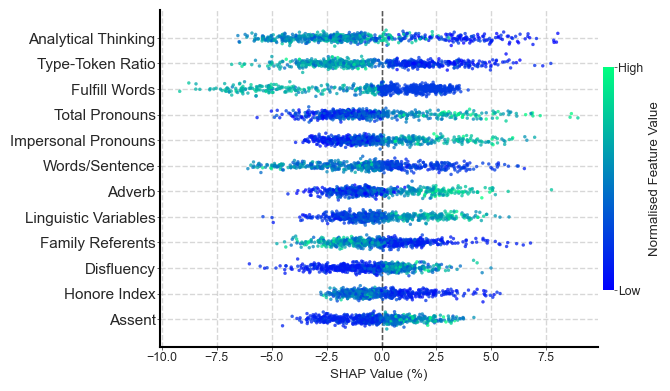

In [13]:
import matplotlib.pyplot as plt
from utils import plotting
plt.close()


# changing the names of the features to the group names and plotting
# the shap values as normal

with plotting.paper_theme():

    fig, ax = plt.subplots(1,1,figsize=(7, 4))

    ax = ml.ShapDisplay.from_shap_values(
        shap_values_df,
        n_features_plot=12,
        ax=ax
    )
    plt.tight_layout()
    plt.savefig('./[figs]/shap_size100.pdf', dpi=600)
    plt.savefig('./[figs]/shap_size100.png', dpi=600)
    plt.show()

#### Single predictions

In [46]:
# top_3_rows = shap_values_df.nsmallest(300, 'y_proba')
top_3_rows = shap_values_df.nlargest(300, 'y_proba')
top_3_rows

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
35521,21,Word Count,-0.281464,5,0.491745,0.485001,1,0.962000,39
35592,21,Analytical Thinking,6.542487,5,-1.073161,-1.105690,1,0.962000,39
35663,21,Clout,0.791651,5,1.073328,0.997416,1,0.962000,39
35734,21,Authentic,1.261389,5,0.387243,0.487220,1,0.962000,39
35805,21,Tone,-0.265286,5,-0.702933,-0.791794,1,0.962000,39
...,...,...,...,...,...,...,...,...,...
49388,43,Brunet,0.248073,6,1.645113,1.561027,1,0.930476,37
49459,43,Honore Index,1.159890,6,-0.942348,-0.931988,1,0.930476,37
49530,43,Type-Token Ratio,1.119986,6,-0.770135,-0.613273,1,0.930476,37
49601,43,Pidensity,-0.248730,6,0.603539,0.554844,1,0.930476,37


/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


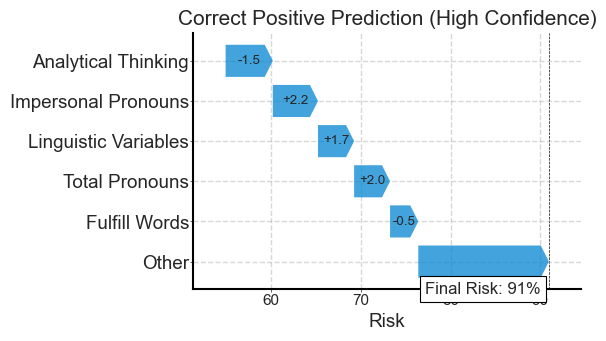

In [7]:
point = 43

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
   
    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
    
    plt.title("Correct Positive Prediction (High Confidence)", fontsize=15)
    plt.tight_layout()
    plt.savefig('./[figs]/shap_single_features_size100_AD_3.png', dpi=600)
    plt.savefig('./[figs]/shap_single_features_size100_AD_3.pdf', dpi=600)
    
    plt.show()

In [42]:
shap_values_df[shap_values_df.Point == 43].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
43,43,Word Count,-0.568459,0,1.039874,0.995811,1,0.909595,37
114,43,Analytical Thinking,5.264717,0,-1.484745,-1.531396,1,0.909595,37
185,43,Clout,-0.096618,0,-0.870126,-0.912452,1,0.909595,37
256,43,Authentic,-0.495257,0,1.601307,1.691568,1,0.909595,37
327,43,Tone,0.162744,0,-0.764144,-0.791794,1,0.909595,37


/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


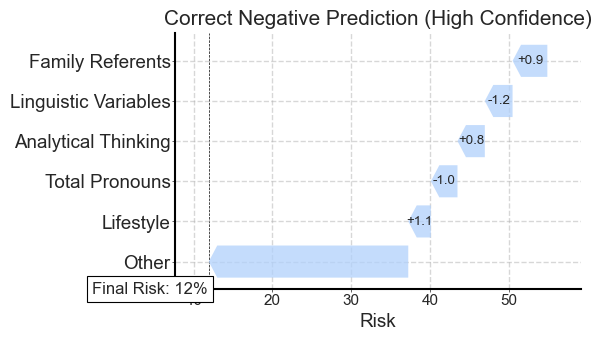

In [15]:
point = 68

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)

    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
    plt.title("Correct Negative Prediction (High Confidence)", fontsize=15)
    plt.tight_layout()
    plt.savefig('./[figs]/shap_single_features_size100_CN.pdf', dpi=600)
    plt.savefig('./[figs]/shap_single_features_size100_CN.png', dpi=600)
    
    plt.show()

In [43]:
shap_values_df[shap_values_df.Point == 68].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
68,68,Word Count,-0.534597,0,2.117499,2.066864,0,0.119238,55
139,68,Analytical Thinking,-3.470737,0,0.821297,0.727935,0,0.119238,55
210,68,Clout,-0.164710,0,0.755154,0.735522,0,0.119238,55
281,68,Authentic,0.386486,0,-1.319018,-1.205621,0,0.119238,55
352,68,Tone,-0.429642,0,-0.537486,-0.554370,0,0.119238,55


#### Lower confidence

/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


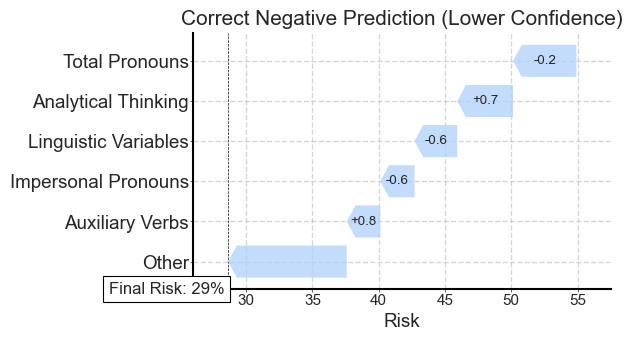

In [18]:
point = 47

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6.3, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
    
    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)

    plt.title("Correct Negative Prediction (Lower Confidence)", fontsize=15)
    plt.tight_layout()

    plt.savefig('./[figs]/shap_single_features_size100_CN_only.pdf', dpi=600)
    plt.savefig('./[figs]/shap_single_features_size100_CN_only.png', dpi=600)
    plt.show()

In [51]:
shap_values_df[shap_values_df.Point == 47].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
47,47,Word Count,0.323168,0,-0.601433,-0.635485,0,0.286333,45
118,47,Analytical Thinking,-4.215150,0,0.692644,0.601888,0,0.286333,45
189,47,Clout,-0.312630,0,-0.551887,-0.589769,0,0.286333,45
260,47,Authentic,-0.468880,0,-0.466681,-0.360036,0,0.286333,45
331,47,Tone,-0.176545,0,1.656739,1.744075,0,0.286333,45


/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


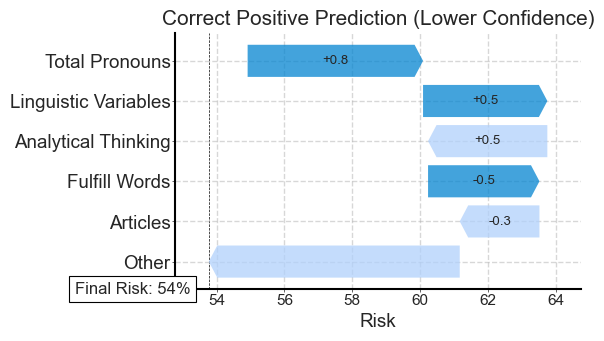

In [13]:
point = 29

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
    
    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
    plt.title("Correct Positive Prediction (Lower Confidence)", fontsize=15)
    plt.tight_layout()
    plt.savefig('./[figs]/shap_single_features_size100_AD_only.pdf', dpi=600)
    plt.savefig('./[figs]/shap_single_features_size100_AD_only.png', dpi=600)
    
    plt.show()

In [118]:
shap_values_df[shap_values_df.Point == 29].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
29,29,Word Count,-1.391147,0,1.189083,1.144111,1,0.537667,32
100,29,Analytical Thinking,-3.520070,0,0.510241,0.423180,1,0.537667,32
171,29,Clout,0.341904,0,0.597472,0.575638,1,0.537667,32
242,29,Authentic,-0.492353,0,0.307467,0.407978,1,0.537667,32
313,29,Tone,-0.093980,0,1.020789,1.077918,1,0.537667,32


In [63]:
shap_values_df[shap_values_df.Point == 28].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
28,28,Word Count,0.414156,0,-0.667748,-0.701396,0,0.436667,26
99,28,Analytical Thinking,-2.012276,0,1.224941,1.123402,0,0.436667,26
170,28,Clout,-0.371658,0,-1.424890,-1.474962,0,0.436667,26
241,28,Authentic,0.588578,0,1.688934,1.778500,0,0.436667,26
312,28,Tone,-0.072493,0,0.023493,0.033254,0,0.436667,26


/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


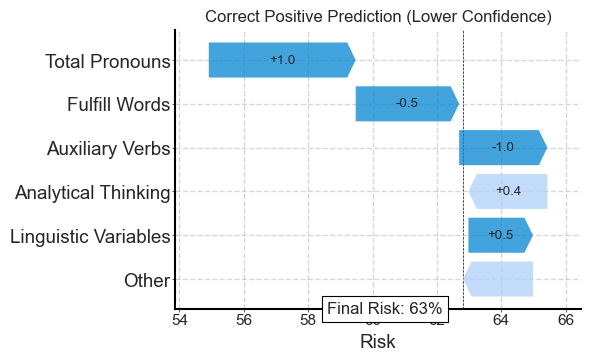

In [11]:
point = 9

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
    
    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
    plt.tight_layout()
    plt.savefig('./[figs]/shap_single_features_size100_AD_only.pdf', dpi=600)
    plt.savefig('./[figs]/shap_single_features_size100_AD_only.png', dpi=600)
    plt.title("Correct Positive Prediction (Lower Confidence)", fontsize=12)
    plt.show()

In [44]:
shap_values_df[shap_values_df.Point == 9].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
9,9,Word Count,0.521262,0,-0.551696,-0.586051,1,0.628119,63
80,9,Analytical Thinking,-2.451396,0,0.393032,0.308345,1,0.628119,63
151,9,Clout,0.197047,0,1.230666,1.217673,1,0.628119,63
222,9,Authentic,-0.184291,0,-0.330185,-0.224622,1,0.628119,63
293,9,Tone,-0.187851,0,0.798053,0.844604,1,0.628119,63


/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


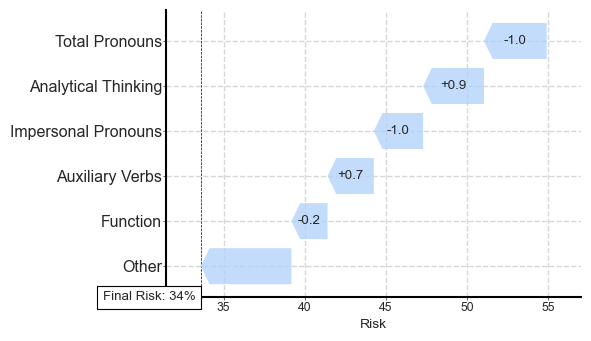

In [32]:
point = 18

plt.close()
with plotting.paper_theme():
    # print(shap_base_values)
    base = shap_base_values[0]*100
    fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

    shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
        columns={"SHAP Value": "Risk"}
    )

    ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
    
    fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
    plt.tight_layout()
    plt.show()

/Users/mr3418/Desktop/Analysis/utils/ml_pipeline.py:1446: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .sum()


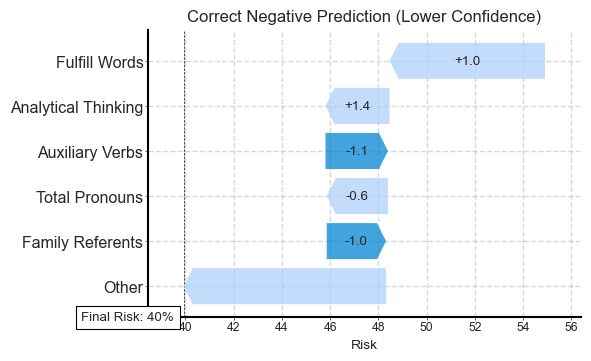

In [40]:
# point = 20

# plt.close()
# with plotting.paper_theme():
#     # print(shap_base_values)
#     base = shap_base_values[0]*100
#     fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

#     shap_values_point_df = shap_values_df.query("run == 0").query("Point == @point").rename(
#         columns={"SHAP Value": "Risk"}
#     )

#     ax = ml.risk_feature_plot(shap_values_point_df, base, ax=ax)
    
#     fig.subplots_adjust(left=0.375, right=0.96, top=0.85, bottom=0.2)
#     plt.tight_layout()
#     plt.savefig('./[figs]/shap_single_features_size100_CN_only.pdf', dpi=600)
#     plt.savefig('./[figs]/shap_single_features_size100_CN_only.png', dpi=600)
#     plt.title("Correct Negative Prediction (Lower Confidence)", fontsize=12)
#     plt.show()

In [45]:
shap_values_df[shap_values_df.Point == 20].head()

,Point,Feature,SHAP Value,run,Value Norm,Value,y_true,y_proba,pid
20,20,Word Count,-0.401794,0,1.321714,1.275932,0,0.399262,11
91,20,Analytical Thinking,-2.656804,0,1.424683,1.319098,0,0.399262,11
162,20,Clout,-0.427730,0,0.061187,0.031864,0,0.399262,11
233,20,Authentic,-0.528041,0,-0.936494,-0.826127,0,0.399262,11
304,20,Tone,-0.189684,0,-0.151731,-0.150293,0,0.399262,11


### External dataset Additional Test

In [50]:
p = './external/Lu/stt_whisper/ad_stt'
df_ad_additional = ml.text_analysis_features(p)
df_ad_additional

Processing 27 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,F01,11.41,1431.59,4.43,0.48,0.00
1,F02,12.20,1195.28,4.33,0.44,0.00
2,F03,10.82,1056.54,3.79,0.58,0.02
3,F04,8.70,3357.21,4.44,0.38,0.00
4,F05,8.92,1469.01,3.59,0.36,0.00
5,F06,8.28,1465.42,3.17,0.26,0.00
6,F08,11.24,1192.12,3.86,0.38,0.00
7,F09,8.82,1448.77,4.20,0.43,0.02
8,F10,12.09,1331.97,4.93,0.47,0.00
9,F11,10.98,1582.59,5.17,0.48,0.01


In [51]:
p = './external/Lu/stt_whisper/cn_stt'
df_cn_additional = ml.text_analysis_features(p)

Processing 27 files


In [54]:
df_test_ext_cn = pd.read_csv('./external/Lu/liwc/updated/LIWC-22 Results - cn_stt_mod - LIWC Analysis.csv')
df_test_ext_cn = df_test_ext_cn.drop(columns=drop_new)
df_test_ext_cn = df_test_ext_cn.iloc[:, :-7]
df_test_ext_cn['Filename'] = df_test_ext_cn['Filename'].str.extract(r'(...)\.')
df_test_ext_cn = df_test_ext_cn.merge(df_cn_additional, left_on='Filename', right_on='PID', how='left')
df_test_ext_cn.drop(columns=['PID'], inplace=True)
df_test_ext_cn.loc[:, 'label'] = 0

df_test_ext_ad = pd.read_csv('./external/Lu/liwc/updated/LIWC-22 Results - ad_stt_mod - LIWC Analysis.csv')
df_test_ext_ad = df_test_ext_ad.drop(columns=drop_new)
df_test_ext_ad = df_test_ext_ad.iloc[:, :-7]
df_test_ext_ad['Filename'] = df_test_ext_ad['Filename'].str.extract(r'(...)\.')
df_test_ext_ad = df_test_ext_ad.merge(df_ad_additional, left_on='Filename', right_on='PID', how='left')
df_test_ext_ad.drop(columns=['PID'], inplace=True)
df_test_ext_ad.loc[:, 'label'] = 1

df_additional = pd.concat([df_test_ext_cn, df_test_ext_ad], ignore_index=True)
df_additional.head()

,Filename,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic,...,Conversation,assent,nonflu,filler,Brunet,Honore,CTTR,PIDensity,Duplic,label
0,F31,59,58.98,84.73,65.66,98.08,5.36,15.25,98.31,79.66,...,5.08,1.69,3.39,0,9.35,1420.89,4.20,0.47,0.00,0
1,F26,70,39.70,99.00,24.32,20.23,5.83,5.71,91.43,87.14,...,4.29,1.43,2.86,0,9.93,1691.57,4.45,0.36,0.01,0
2,F32,85,50.27,12.77,23.38,3.29,7.08,12.94,94.12,80.00,...,2.35,0.00,2.35,0,9.85,1353.86,4.24,0.39,0.00,0
3,F33,191,69.19,70.45,51.49,14.50,13.64,13.61,90.58,72.25,...,0.52,0.52,0.00,0,12.38,1363.32,4.77,0.43,0.00,0
4,F37,90,36.50,40.06,10.18,54.76,18.00,7.78,92.22,77.78,...,1.11,0.00,1.11,0,10.25,1366.04,3.94,0.41,0.00,0


In [55]:
# Function to concatenate the right columns into a single array
def combine_features_liwc(row):
    return np.array(row[1:-1])

# Apply this function to each row
df_additional['data'] = df_additional.apply(combine_features_liwc, axis=1)
df_additional = df_additional.rename(columns={'Filename': 'pid'})
df_additional = df_additional[['pid', 'label', 'data']]
df_additional.head()

,pid,label,data
0,F31,0,"[59, 58.98, 84.73, 65.66, 98.08, 5.36, 15.25, ..."
1,F26,0,"[70, 39.7, 99.0, 24.32, 20.23, 5.83, 5.71, 91...."
2,F32,0,"[85, 50.27, 12.77, 23.38, 3.29, 7.08, 12.94, 9..."
3,F33,0,"[191, 69.19, 70.45, 51.49, 14.5, 13.64, 13.61,..."
4,F37,0,"[90, 36.5, 40.06, 10.18, 54.76, 18.0, 7.78, 92..."


In [56]:
df_additional.data[0].shape

(100,)

In [57]:
PATH_SAVE = './external/lu/liwc/'
df_additional.to_pickle(PATH_SAVE + 'liwc22-size100-raw.pkl')

In [61]:
with open('./external/lu/liwc/liwc22-size100-raw.pkl', 'rb') as f:
    liwc_ext = pickle.load(f)

X_test = liwc_ext['data']
y_test = liwc_ext['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc-size100')
# best_hyperparams = best_hyperparams['Random Forest']
# best_hyperparams

In [62]:
evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

{'Logistic Regression': ('72.6 (68.2 - 77.0)',
  '75.2 (68.3 - 82.0)',
  '79.9 (76.1 - 83.7)',
  '73.9 (71.0 - 76.8)'),
 'SVM': ('76.7 (72.0 - 81.3)',
  '70.4 (61.5 - 79.3)',
  '80.6 (77.1 - 84.1)',
  '73.5 (69.6 - 77.4)'),
 'Random Forest': ('80.0 (77.2 - 82.8)',
  '74.1 (69.6 - 78.6)',
  '84.6 (82.8 - 86.4)',
  '77.0 (74.6 - 79.5)'),
 'Neural Network': ('66.3 (59.8 - 72.8)',
  '59.6 (49.8 - 69.5)',
  '65.2 (59.1 - 71.2)',
  '63.0 (57.2 - 68.7)'),
 'XGBoost': ('80.7 (77.3 - 84.2)',
  '69.3 (64.4 - 74.1)',
  '82.9 (80.7 - 85.2)',
  '75.0 (72.4 - 77.6)')}

### Pilot Data: English + Spanish but using TRANSLATION!! to be able to use the LIWC Dict

In [66]:
p = './external/HRI/stt-S1/english'
df_pilot_1 = ml.text_analysis_features(p)
df_pilot_1

Processing 14 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,P02,13.44,1160.16,4.23,0.46,0.01
1,P04,10.22,1585.57,4.67,0.45,0.00
2,P05,13.66,1127.33,4.30,0.44,0.04
3,P06,9.70,1878.14,3.95,0.34,0.01
4,P07,9.30,1404.89,3.14,0.45,0.04
5,P08,8.65,1660.10,3.76,0.42,0.02
6,P09,9.71,1551.17,3.89,0.29,0.01
7,P10,9.82,1304.89,3.63,0.37,0.06
8,P12,8.94,1789.05,3.78,0.38,0.00
9,P13,10.91,958.53,3.80,0.47,0.03


In [64]:
p = './external/HRI/stt-S1/translated'
df_pilot_2 = ml.text_analysis_features(p)
df_pilot_2

Processing 8 files


,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,P17,10.94,1221.24,4.12,0.37,0.03
1,P19,9.97,1838.97,3.58,0.36,0.01
2,P20,9.89,2545.57,4.32,0.30,0.01
3,P21,9.28,1819.71,3.65,0.34,0.00
4,P22,8.28,866.43,2.50,0.28,0.03
5,P23,9.22,2518.48,4.42,0.43,0.01
6,P24,8.01,1524.92,2.75,0.18,0.00
7,P25,9.20,1233.26,3.80,0.36,0.00


In [67]:
df_pilot = pd.concat([df_pilot_1, df_pilot_2], ignore_index=True)
df_pilot

,PID,Brunet,Honore,CTTR,PIDensity,Duplic
0,P02,13.44,1160.16,4.23,0.46,0.01
1,P04,10.22,1585.57,4.67,0.45,0.00
2,P05,13.66,1127.33,4.30,0.44,0.04
3,P06,9.70,1878.14,3.95,0.34,0.01
4,P07,9.30,1404.89,3.14,0.45,0.04
5,P08,8.65,1660.10,3.76,0.42,0.02
6,P09,9.71,1551.17,3.89,0.29,0.01
7,P10,9.82,1304.89,3.63,0.37,0.06
8,P12,8.94,1789.05,3.78,0.38,0.00
9,P13,10.91,958.53,3.80,0.47,0.03


In [68]:
demo = pd.read_csv('./external/HRI/demographics.csv')
demo.rename(columns=lambda x: x.lower(), inplace=True)
demo['mmse_split'] = ''
demo.loc[demo['mmse'] < 10, 'mmse_split'] = 'ad-sev'
demo.loc[(demo['mmse'] >= 10) & (demo['mmse'] <= 20), 'mmse_split'] = 'ad-mod'
demo.loc[(demo['mmse'] >= 21) & (demo['mmse'] <= 26), 'mmse_split'] = 'ad-mil'
demo.loc[demo['mmse'] > 26, 'mmse_split'] = 'cn'
demo['label'] = demo['mmse_split'].apply(lambda x: 0 if x == 'cn' else 1)
demo.head()

,pid,age,gender,mmse,language,mmse_split,label
0,P02,70,F,27,English,cn,0
1,P04,81,M,29,English,cn,0
2,P05,84,F,23,English,ad-mil,1
3,P06,68,M,25,English,ad-mil,1
4,P07,95,M,15,English,ad-mod,1


In [69]:
PATH = './external/HRI/liwc/newLIWC22/'
df_en = pd.read_csv(PATH + 'LIWC-22 Results - S1 english - LIWC Analysis.csv')
df_en = df_en.drop(columns=drop_new)
df_en = df_en.iloc[:, :-7]
df_en['Filename'] = df_en['Filename'].str.extract(r'(...)\.')

df_translated = pd.read_csv(PATH + 'LIWC-22 Results - S1 translated - LIWC Analysis.csv')
df_translated = df_translated.drop(columns=drop_new)
df_translated = df_translated.iloc[:, :-7]
df_translated['Filename'] = df_translated['Filename'].str.extract(r'(...)\.')

df_liwc_pilot = pd.concat([df_en, df_translated], ignore_index=True)

df_liwc_pilot = df_liwc_pilot.merge(df_pilot, left_on='Filename', right_on='PID', how='left')
df_liwc_pilot = df_liwc_pilot.drop(columns=['PID'])
df_liwc_pilot

,Filename,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,Dic,Linguistic,...,focusfuture,Conversation,assent,nonflu,filler,Brunet,Honore,CTTR,PIDensity,Duplic
0,P13,111,23.42,66.53,87.00,20.23,12.33,4.50,90.99,86.49,...,0.00,4.50,0.90,3.60,0,10.91,958.53,3.80,0.47,0.03
1,P07,52,1.84,1.00,99.00,79.29,10.40,3.85,100.00,88.46,...,1.92,7.69,0.00,7.69,0,9.30,1404.89,3.14,0.45,0.04
2,P06,74,99.00,83.39,3.49,20.23,12.33,14.86,87.84,66.22,...,2.70,2.70,2.70,0.00,0,9.70,1878.14,3.95,0.34,0.01
3,P12,57,41.78,50.51,45.82,20.23,5.70,15.79,91.23,73.68,...,0.00,7.02,1.75,5.26,0,8.94,1789.05,3.78,0.38,0.00
4,P04,106,62.77,62.44,48.58,10.80,15.14,13.21,90.57,75.47,...,1.89,0.94,0.94,0.00,0,10.22,1585.57,4.67,0.45,0.00
5,P10,73,98.88,83.81,28.97,20.23,10.43,13.70,84.93,67.12,...,0.00,2.74,1.37,1.37,0,9.82,1304.89,3.63,0.37,0.06
6,P05,267,24.96,90.78,2.33,3.64,10.68,14.23,92.51,76.78,...,2.62,1.87,0.75,1.12,0,13.66,1127.33,4.30,0.44,0.04
7,P15,118,94.24,30.62,47.65,11.57,4.72,11.02,81.36,66.10,...,0.85,2.54,0.85,1.69,0,10.78,1707.40,4.43,0.28,0.00
8,P14,36,58.02,84.23,39.59,20.23,7.20,8.33,97.22,77.78,...,5.56,0.00,0.00,0.00,0,7.73,2150.11,3.54,0.43,0.00
9,P16,48,94.18,40.06,39.59,20.23,16.00,12.50,85.42,72.92,...,0.00,0.00,0.00,0.00,0,8.89,1238.78,3.27,0.37,0.00


In [70]:
# Function to concatenate the right columns into a single array
def combine_features_liwc(row):
    return np.array(row[1:])

# Apply this function to each row
df_liwc_pilot['data'] = df_liwc_pilot.apply(combine_features_liwc, axis=1)
df_liwc_pilot = df_liwc_pilot.rename(columns={'Filename': 'pid'})
df_liwc_pilot = df_liwc_pilot[['pid', 'data']]
df_liwc_pilot.head()


,pid,data
0,P13,"[111, 23.42, 66.53, 87.0, 20.23, 12.33, 4.5, 9..."
1,P07,"[52, 1.84, 1.0, 99.0, 79.29, 10.4, 3.85, 100.0..."
2,P06,"[74, 99.0, 83.39, 3.49, 20.23, 12.33, 14.86, 8..."
3,P12,"[57, 41.78, 50.51, 45.82, 20.23, 5.7, 15.79, 9..."
4,P04,"[106, 62.77, 62.44, 48.58, 10.8, 15.14, 13.21,..."


In [71]:
df_liwc_pilot.data[0].shape

(100,)

In [73]:
df_hri = df_liwc_pilot.merge(demo, left_on='pid', right_on='pid', how='left')
df_hri.data[0].shape    

(100,)

In [74]:
# df_hri.to_pickle("./external/HRI/liwc/newLIWC22/df_liwc_all-size100.pkl")

In [3]:
with open("./external/HRI/liwc/newLIWC22/df_liwc_all-size100.pkl", "rb") as f:
    df_hri = pickle.load(f)
df_hri.head()

,pid,data,age,gender,mmse,language,mmse_split,label
0,P13,"[111, 23.42, 66.53, 87.0, 20.23, 12.33, 4.5, 9...",93,M,23,English,ad-mil,1
1,P07,"[52, 1.84, 1.0, 99.0, 79.29, 10.4, 3.85, 100.0...",95,M,15,English,ad-mod,1
2,P06,"[74, 99.0, 83.39, 3.49, 20.23, 12.33, 14.86, 8...",68,M,25,English,ad-mil,1
3,P12,"[57, 41.78, 50.51, 45.82, 20.23, 5.7, 15.79, 9...",75,F,25,English,ad-mil,1
4,P04,"[106, 62.77, 62.44, 48.58, 10.8, 15.14, 13.21,...",81,M,29,English,cn,0


In [4]:
df_hri.mmse_split.value_counts()

ad-mil    12
cn         8
ad-mod     2
Name: mmse_split, dtype: int64

In [6]:
12/22*100, 8/22*100, 2/22*100

(54.54545454545454, 36.36363636363637, 9.090909090909092)

In [11]:
X_test = df_hri['data']
y_test = df_hri['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc-size100')
best_hyperparams


{'Logistic Regression': LogisticRegression(C=0.14024971326600358, max_iter=10000, penalty='l1',
                    random_state=42, solver='liblinear'),
 'SVM': SVC(C=0.0024604229580184175, gamma=5.2471211886275886e-05, kernel='linear',
     probability=True, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=16, min_samples_leaf=3, min_samples_split=4,
                        n_estimators=50, random_state=42),
 'Neural Network': MLPClassifier(activation='logistic', alpha=0.00016676611460145473,
               batch_size=64, hidden_layer_sizes=(400,),
               learning_rate='adaptive',
               learning_rate_init=0.0018595691547710715, max_iter=10000,
               random_state=42, solver='sgd'),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7484098603570379, device=None,
               early_stopping_rounds=None, enable_categorical=

In [12]:
evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

Logistic Regression
SVM
Random Forest
Neural Network
XGBoost


{'Logistic Regression': ('72.1 (64.0 - 80.3)',
  '41.2 (30.1 - 52.4)',
  '63.4 (60.4 - 66.4)',
  '60.9 (56.8 - 65.0)'),
 'SVM': ('63.6 (58.5 - 68.7)',
  '51.2 (41.4 - 61.1)',
  '62.6 (60.2 - 64.9)',
  '59.1 (55.7 - 62.5)'),
 'Random Forest': ('70.0 (58.0 - 82.0)',
  '52.5 (39.3 - 65.7)',
  '62.5 (54.9 - 70.1)',
  '63.6 (54.7 - 72.6)'),
 'Neural Network': ('75.7 (66.0 - 85.4)',
  '33.8 (20.4 - 47.1)',
  '58.8 (51.3 - 66.2)',
  '60.5 (52.8 - 68.1)'),
 'XGBoost': ('85.7 (78.9 - 92.5)',
  '35.0 (26.8 - 43.2)',
  '64.0 (60.3 - 67.8)',
  '67.3 (63.0 - 71.6)')}

In [13]:
# Save the dictionary as a pickle file
name = 'liwc22-size100-probs-pilot'
with open(f'./external/hri/probs/{name}.pkl', 'wb') as f:
    pickle.dump(probs, f)

### Regression on test, test2, pilot data

In [13]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    train_size100 = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)

with open('./external/lu/liwc/liwc22-size100-raw.pkl', 'rb') as f:
    ext_size100 = pickle.load(f)

with open('./external/hri/liwc/newLIWC22/df_liwc_all-size100.pkl', 'rb') as f:
    hri_size100 = pickle.load(f)

groups = pd.read_csv('mapping.csv')

In [14]:
df_all = pd.read_csv('./dx-mmse.csv')
# Select only the specified columns
selected_columns = ['age', 'gender', 'mmse', 'dx', 'adressfname', 'test', 'pid']
df_all['pid'] = df_all['adressfname'].str.extract(r'(\d{3})$')
df_all = df_all[selected_columns]
df_train = df_all[df_all['test'] == False]
df_test = df_all[df_all['test'] == True]
df_test

,age,gender,mmse,dx,adressfname,test,pid
2,74,female,30.0,Control,adrso004,True,004
4,65,female,28.0,Control,adrso006,True,006
7,68,female,29.0,Control,adrso009,True,009
9,71,female,30.0,Control,adrso011,True,011
11,70,female,29.0,Control,adrso013,True,013
...,...,...,...,...,...,...,...
225,66,male,29.0,Control,adrso303,True,303
226,70,male,30.0,Control,adrso304,True,304
232,63,female,28.0,Control,adrso313,True,313
233,61,female,29.0,Control,adrso314,True,314


In [4]:
df_train.head()

,age,gender,mmse,dx,adressfname,test,pid
0,70,female,26.0,Control,adrso002,False,002
1,72,female,30.0,Control,adrso003,False,003
3,67,female,27.0,Control,adrso005,False,005
5,62,female,30.0,Control,adrso007,False,007
6,67,female,29.0,Control,adrso008,False,008


In [5]:
train_size100.head()

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."


In [6]:
'002' in train_size100.pid.to_list()

True

In [8]:
train_size100.data[0].shape

(100,)

In [15]:
df_reg = train_size100.merge(df_train, left_on='pid', right_on='pid', how='left')
df_reg['mmse'] = df_reg['mmse'].round().astype(int)
df_reg.head()

,pid,label,data,age,gender,mmse,dx,adressfname,test
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9...",64,female,30,Control,adrso267,False
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ...",67,female,30,Control,adrso273,False
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ...",68,female,30,Control,adrso298,False
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7...",70,male,29,Control,adrso307,False
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ...",67,female,29,Control,adrso312,False


In [16]:
X = df_reg['data']
y = df_reg['mmse']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

In [22]:
### CHANGE feature_set = 

models_regression = ml.create_regression_models()
param_grids_regression = ml.create_param_grids_regression()

# model selection and crossvalidation
results = []
for name, model in models_regression.items():
    result = ml.crossvalidation_regression(name, model, param_grids_regression[name], X_scaled_train, y, feature_set = 'w-liwc-size100')
    results.append(result)

df_eval_cv = pd.DataFrame(results)
df_eval_cv
# takes 3 min to run 

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits


/Users/mr3418/opt/anaconda3/envs/phd_analysis_env/lib/python3.11/site-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 48 candidates, totalling 480 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits


,Model,RMSE,MAE
0,Ridge,7.5 (1.3),6.0 (1.2)
1,SVR,6.4 (1.2),5.3 (0.9)
2,RFR,5.9 (0.7),4.8 (0.5)
3,MLP,8.3 (1.8),6.6 (1.7)
4,XGBoost,5.9 (0.8),4.8 (0.5)


In [132]:
import os
import joblib
feature_abbr = 'w-liwc-size100'
model_abbr = 'regression_rfr'
filename = f"10fcv_{model_abbr}.pkl"
file_path = os.path.join("./hyperparam-tuning-UPD", feature_abbr, filename)
if os.path.exists(file_path):
    best_model_reg = joblib.load(file_path)
best_model_reg

RandomForestRegressor(min_samples_leaf=2, random_state=42)

Test

In [17]:
groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)
groups = groups.sort_values('pid').reset_index(drop=True)
df_reg_test = test_size100.merge(groups, left_on='pid', right_on='pid', how='left')
# IMPORTANT: remove outlier without MMSE 
df_reg_test = df_reg_test[df_reg_test['pid'] != '54']
df_reg_test['mmse'] = df_reg_test['mmse'].round().astype(int)
df_reg_test.head()

,pid,label,data,adressfname,gender,dx,age,mmse,mmse_split,age_split
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",adrso013,female,Control,70,29,cn,70-80
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",adrso038,female,ProbableAD,65,24,ad-mil,60-69
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",adrso214,male,ProbableAD,56,18,ad-mod,50-59
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",adrso083,male,ProbableAD,78,24,ad-mil,70-80
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",adrso166,female,Control,58,30,cn,50-59


In [18]:
groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)
groups = groups.sort_values('pid').reset_index(drop=True)
groups.head()

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso108,male,ProbableAD,65,19.0,1,ad-mod,60-69
1,adrso171,female,Control,57,27.0,10,cn,50-59
2,adrso184,female,Control,78,30.0,11,cn,70-80
3,adrso293,female,Control,57,30.0,12,cn,50-59
4,adrso113,female,ProbableAD,69,20.0,13,ad-mod,60-69


In [103]:
len(groups)

71

In [104]:
groups.mmse_split.value_counts()

cn        36
ad-mod    21
ad-mil    11
ad-sev     2
Name: mmse_split, dtype: int64

In [19]:
# check if there are any missing values
df_reg_test['mmse'].isna().sum()


0

In [23]:
### CHANGE feature_set = 

X_test = df_reg_test['data']
y_test = df_reg_test['mmse']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_regression(feature_set = 'w-liwc-size100')

# modified bootstrap function
eval, preds = ml.fit_and_evaluate_bootstrap_regression(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(eval)
df = evaluation_bootstrap_df.round(1)
df

>>>Now processing model Ridge
>>>Now processing model SVR
>>>Now processing model RFR
>>>Now processing model MLP
>>>Now processing model XGBoost


,Model,MAE Mean,MAE Lower CI,MAE Upper CI,RMSE Mean,RMSE Lower CI,RMSE Upper CI
0,Ridge,5.1,4.8,5.4,7.0,6.5,7.6
1,SVR,4.1,4.0,4.2,5.0,4.9,5.1
2,RFR,3.7,3.7,3.8,4.7,4.6,4.8
3,MLP,5.8,5.5,6.1,7.3,7.0,7.7
4,XGBoost,3.7,3.6,3.9,4.7,4.6,4.9


In [24]:
# # Save the dictionary as a pickle file
# with open('./evaluation-test-UPD/predict_reg/predicted_liwc_size100.pkl', 'wb') as f:
#     pickle.dump(preds, f)

In [19]:
with open(f'./evaluation-test-UPD/predict_reg/predicted_liwc_size100.pkl', 'rb') as f:
    predicted = pickle.load(f)

bestmodel = 'RFR'
probs_bestmodel = predicted[f'{bestmodel}']
probs_bestmodel

[array([22.48483333, 21.63815476, 19.87016667, 15.253     , 26.76742857,
        25.41427778, 21.8842381 , 26.1132381 , 21.89444048, 18.85130952,
        26.7835    , 21.56519048, 21.12547619, 28.89833333, 19.10890476,
        12.58691667, 20.02788095, 28.49678571, 27.10369048, 26.14738095,
        25.95359524, 17.40858333, 21.37730952, 16.69135714, 20.11346429,
        22.38634524, 23.77729762, 22.64171429, 26.08347619, 23.52621429,
        21.86053571, 28.55521429, 21.60407143, 24.28159524, 24.6410119 ,
        22.41691667, 25.99403571, 26.86896429, 25.62652381, 26.27604762,
        21.5865119 , 20.6922381 , 23.25296429, 12.1045    , 25.87566667,
        27.99766667, 26.16469048, 26.22315476, 23.13235714, 27.64354762,
        18.68283333, 26.57290476, 28.13211905, 26.02728571, 18.19566667,
        28.6495    , 27.6562381 , 18.1020119 , 25.89680952, 16.8445    ,
        22.94578571, 25.89790476, 25.56078571, 22.53645238, 28.2052619 ,
        26.71835714, 22.14666667, 29.54464286, 22.6

#### Calc regression plot without the 10 bootstrap samples

In [20]:
import numpy as np

mean_probs = np.mean(probs_bestmodel, axis=0)
mean_probs

array([24.52553532, 21.90843095, 22.04071291, 16.79372594, 27.89850357,
       25.38303175, 22.24947128, 26.99455952, 22.68300556, 22.28054087,
       24.5465119 , 22.37535635, 22.52441746, 27.63065556, 18.15448651,
       16.39731468, 20.0413066 , 27.90488254, 26.23476032, 25.68772897,
       26.77697262, 14.95699286, 23.49702937, 15.41089365, 20.2878996 ,
       24.03540119, 23.43712341, 22.98015357, 25.69854683, 22.65746746,
       21.67963413, 26.908175  , 21.4726873 , 25.22297183, 25.28448452,
       20.41200159, 26.29795913, 26.49279802, 26.17069206, 25.87175357,
       23.61522738, 20.8464373 , 25.26431786, 13.91970992, 26.03860952,
       27.02744444, 25.63540714, 26.49020754, 25.33423835, 27.06795714,
       17.93903373, 25.23241627, 28.49479048, 26.04428849, 16.01179881,
       27.36335079, 27.77744921, 19.23759365, 25.13929365, 13.8524254 ,
       23.84827857, 24.79494643, 24.33071429, 23.68775913, 26.80345119,
       27.50970913, 22.13529351, 28.81878968, 24.01698492, 18.24

In [11]:
mean_probs.size

70

In [21]:
s = ['pid', 'mmse', 'data', 'mmse_split']
df_groups = df_reg_test[s]
df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')
df_groups.head()

/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_7566/1831904705.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')


,pid,mmse,data,mmse_split
0,58,29,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",cn
1,64,24,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",ad-mil
2,70,18,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",ad-mod
3,71,24,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",ad-mil
4,65,30,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",cn


In [22]:
df_groups.shape

(70, 4)

In [23]:
y_proba_df_all = pd.DataFrame(mean_probs.round(2), columns=['y_pred'])
y_proba_df_all['pid'] = df_groups['pid']
y_proba_df_all['y_true'] = df_groups['mmse']
y_proba_df_all['error'] = abs(y_proba_df_all['y_true'] - y_proba_df_all['y_pred'])
y_proba_df_all['cog_group'] = df_groups['mmse_split']
y_proba_df_all.head()


,y_pred,pid,y_true,error,cog_group
0,24.53,58,29.0,4.47,cn
1,21.91,64,24.0,2.09,ad-mil
2,22.04,70,18.0,4.04,ad-mod
3,16.79,71,24.0,7.21,ad-mil
4,27.90,65,30.0,2.10,cn


In [206]:
len(y_proba_df_all)

70

In [50]:
y_proba_df_all[y_proba_df_all.cog_group == 'ad-sev']

,y_pred,pid,y_true,error,cog_group
23,15.41,29,5.0,10.41,ad-sev
54,16.01,46,8.0,8.01,ad-sev


In [54]:
y_proba_df_all[y_proba_df_all.error > 8]

,y_pred,pid,y_true,error,cog_group
23,15.41,29,5.0,10.41,ad-sev
25,24.04,14,16.0,8.04,ad-mod
26,23.44,16,10.0,13.44,ad-mod
54,16.01,46,8.0,8.01,ad-sev


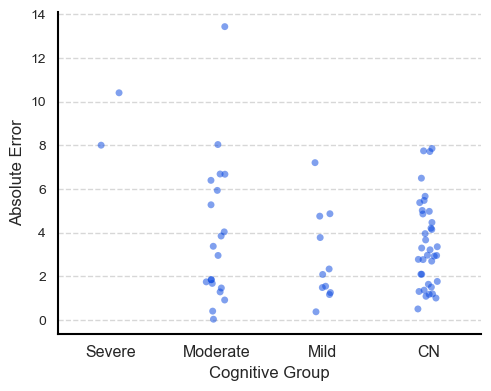

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define the order of the cognitive groups
cog_group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
labels = ['Severe', 'Moderate', 'Mild', 'CN']

colors = [
    'xkcd:marine blue',# "#104E8B",  # dark blue
    'xkcd:cerulean'# 'xkcd:bright blue'
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

# Use your desired plotting theme (e.g., paper_theme)
with plotting.paper_theme():  # Assuming `plotting.paper_theme()` is defined elsewhere in your code
    plt.figure(figsize=(5, 4))
    
    # Create the strip plot with the desired order and single color
    sns.stripplot(x='cog_group', y='error', data=y_proba_df_all, 
                  jitter=True, alpha=0.5, order=cog_group_order, color='xkcd:blue')  # Set color here 'xkcd:cerulean'
    
    plt.xlabel('Cognitive Group', fontsize=12)
    plt.ylabel('Absolute Error', fontsize=12)
    plt.tick_params(labelsize=10)
    plt.xticks(range(len(cog_group_order)), labels, fontsize=11.5
               )  # Set x-axis labels
    plt.tight_layout()
    plt.savefig('./[figs]/regression_single_test.pdf', dpi=600)
    plt.savefig('./[figs]/regression_single_test.png', dpi=600)
    plt.show()


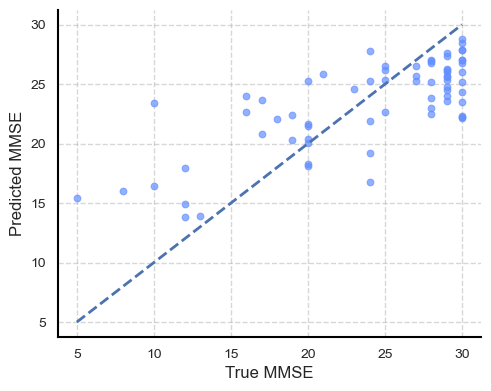

In [59]:
import matplotlib.pyplot as plt

with plotting.paper_theme():
    plt.figure(figsize=(5, 4))
    plt.scatter(y_proba_df_all['y_true'], y_proba_df_all['y_pred'], alpha=0.7)
    plt.plot([y_proba_df_all['y_true'].min(), y_proba_df_all['y_true'].max()], 
            [y_proba_df_all['y_true'].min(), y_proba_df_all['y_true'].max()], 'b--', lw=2)
    plt.xlabel('True MMSE', fontsize=12)
    plt.ylabel('Predicted MMSE', fontsize=12)
    plt.tick_params(labelsize=10)
    plt.tight_layout()
    plt.savefig('./[figs]/regression_line_singledots.pdf', dpi=600)
    plt.savefig('./[figs]/regression_line_singledots.png', dpi=600)
    plt.show()
#     plt.title('True vs Predicted MMSE')




In [27]:
y_proba_df_all.head()

,y_pred,pid,y_true,error,cog_group
0,24.53,58,29.0,4.47,cn
1,21.91,64,24.0,2.09,ad-mil
2,22.04,70,18.0,4.04,ad-mod
3,16.79,71,24.0,7.21,ad-mil
4,27.90,65,30.0,2.10,cn


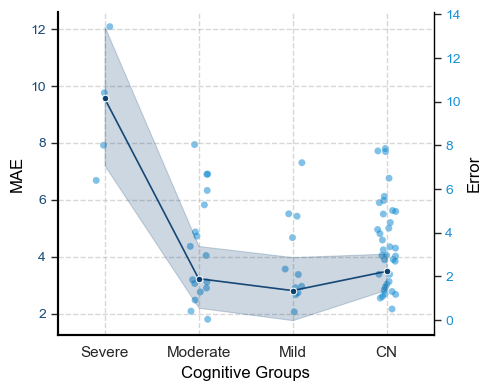

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from utils import plotting
import pandas as pd

# Example DataFrame (replace with your own data if needed)
# df = y_proba_df_all.copy()
df = y_proba_df_all.copy()

colors = [
    'xkcd:marine blue',# "#104E8B",  # dark blue
    'xkcd:cerulean'# 'xkcd:bright blue'
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

# Define bins and bin labels for the MMSE score ranges
bins = [0, 10, 20, 26, 30]
labels = ['Severe', 'Moderate', 'Mild', 'CN']
df['MMSE Groups'] = pd.cut(df['y_true'], bins=bins, labels=labels, include_lowest=True)

# Calculate the absolute error (MAE) for each data point
df['Error'] = np.absolute(df['y_pred'] - df['y_true'])

# Setup the plot with dual axes
with plotting.paper_theme():
    plt.close()
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Line plot for MAE with confidence interval
    ax1 = sns.lineplot(data=df, x='MMSE Groups', y='Error', color=colors[0], marker='o', zorder=10, ci=95)
    ax1.set_ylabel('MAE', color='black', fontsize=12)
    ax1.set_xlabel('Cognitive Groups', color='black', fontsize=12)
    # ax1.set_ylim(0, df['Error'].max() * 1.1)  # Set the MAE y-axis to start at 0
    ax1.tick_params(axis='y', labelcolor=colors[0], labelsize=10)
    ax1.tick_params(axis='x', labelsize=11)

    # Create secondary axis for absolute error jitter plot
    ax2 = ax1.twinx()
    ax2.grid(False)

    # Jitter plot for absolute errors
    sns.stripplot(x='MMSE Groups', y='Error', data=df, jitter=True, alpha=0.5, color=colors[1], ax=ax2)

    # Set label and ticks for the second y-axis (absolute error)
    ax2.set_ylabel('Error', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=colors[1], labelsize=10)
    # Line plot for mean absolute error with std on the right axis


    # Force MAE axis in front
    ax1.set_zorder(ax2.get_zorder() + 1)  # Make ax1 above ax2
    ax1.patch.set_visible(False)  # Hide the 'ax1' background to see 'ax2'

    ax2.spines[['right']].set_visible(True) # activates the right spine
    ax2.spines['right'].set_color('black') # makes sure the right spine is black
    ax2.spines['right'].set_linewidth(1.0) # makes sure the right spine is 1.0 linewidth

    # Optionally set y-limits if needed
    ax2.set_ylim(-df['Error'].max() * 0.05, df['Error'].max()*1.05)  # Increase y-axis limit for better visibility

    # Show plot
    plt.tight_layout()
    # plt.savefig('./[figs]/regression_size100_jitter.pdf', dpi=600)
    # plt.savefig('./[figs]/regression_size100_jitter.png', dpi=600)
    plt.show()


___

In [9]:
probs_bestmodel[0].shape

(70,)

In [24]:
s = ['pid', 'mmse', 'data', 'mmse_split']
df_groups = df_reg_test[s]
df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')
df_groups.head()

/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_7566/1831904705.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_groups.loc[:, 'pid'] = df_groups['pid'].str.replace('adrsdt', '')


,pid,mmse,data,mmse_split
0,58,29,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",cn
1,64,24,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",ad-mil
2,70,18,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",ad-mod
3,71,24,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",ad-mil
4,65,30,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",cn


In [15]:
df_groups.shape

(70, 4)

In [25]:
# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in probs_bestmodel for item in sublist]
p = np.concatenate(probs_bestmodel)
y_proba_df_all = pd.DataFrame(p.round(2), columns=['y_pred'])
y_proba_df_all['pid'] = np.tile(df_groups['pid'], 10)
y_proba_df_all['y_true'] = np.tile(df_groups['mmse'], 10)
y_proba_df_all['error'] = abs(y_proba_df_all['y_true'] - y_proba_df_all['y_pred'])
y_proba_df_all['cog_group'] = np.tile(df_groups['mmse_split'], 10)
y_proba_df_all.copy()
y_proba_df_all.head()

,y_pred,pid,y_true,error,cog_group
0,22.48,58,29,6.52,cn
1,21.64,64,24,2.36,ad-mil
2,19.87,70,18,1.87,ad-mod
3,15.25,71,24,8.75,ad-mil
4,26.77,65,30,3.23,cn


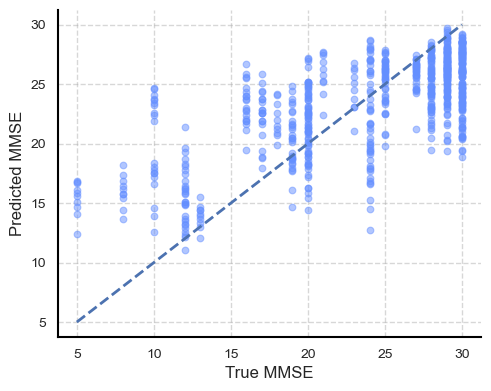

In [45]:
import matplotlib.pyplot as plt

with plotting.paper_theme():
    plt.figure(figsize=(5, 4))
    plt.scatter(y_proba_df_all['y_true'], y_proba_df_all['y_pred'], alpha=0.5)
    plt.plot([y_proba_df_all['y_true'].min(), y_proba_df_all['y_true'].max()], 
            [y_proba_df_all['y_true'].min(), y_proba_df_all['y_true'].max()], 'b--', lw=2)
    plt.xlabel('True MMSE', fontsize=12)
    plt.ylabel('Predicted MMSE', fontsize=12)
    plt.tick_params(labelsize=10)
    plt.tight_layout()
    plt.savefig('./[figs]/regression_line.pdf', dpi=600)
    plt.savefig('./[figs]/regression_line.png', dpi=600)
    plt.show()
#     plt.title('True vs Predicted MMSE')




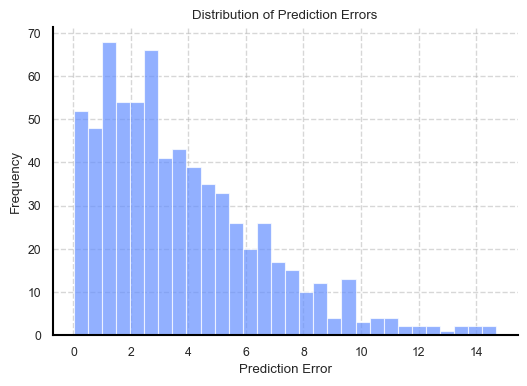

In [63]:
import matplotlib.pyplot as plt

with plotting.paper_theme():
    plt.figure(figsize=(6, 4))
    plt.hist(y_proba_df_all['error'], bins=30, alpha=0.7)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.title('Distribution of Prediction Errors')
    plt.show()


In [38]:
y_proba_df_all.cog_group.unique()

array(['cn', 'ad-mil', 'ad-mod', 'ad-sev'], dtype=object)

In [39]:
y_proba_df_all['Error'] = np.absolute(y_proba_df_all['y_pred'] - y_proba_df_all['y_true'])
y_proba_df_all.head()

,y_pred,pid,y_true,error,cog_group,Error
0,22.48,58,29,6.52,cn,6.52
1,21.64,64,24,2.36,ad-mil,2.36
2,19.87,70,18,1.87,ad-mod,1.87
3,15.25,71,24,8.75,ad-mil,8.75
4,26.77,65,30,3.23,cn,3.23


In [101]:
len(y_proba_df_all)

700

<Figure size 500x400 with 0 Axes>

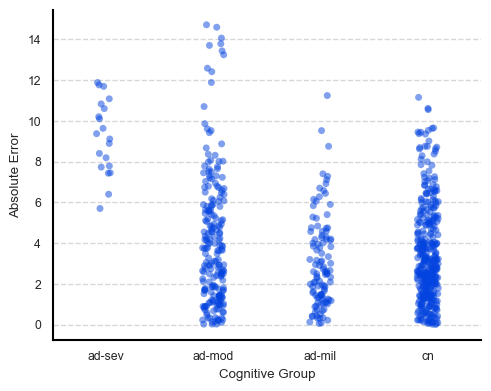

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the order of the cognitive groups
cog_group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']

# Use your desired plotting theme (e.g., paper_theme)
with plotting.paper_theme():  # Assuming `plotting.paper_theme()` is defined elsewhere in your code
    plt.figure(figsize=(5, 4))
    
    # Create the strip plot with the desired order and single color
    sns.stripplot(x='cog_group', y='Error', data=y_proba_df_all, 
                  jitter=True, alpha=0.5, order=cog_group_order, color='xkcd:blue')  # Set color here 'xkcd:cerulean'
    
    plt.xlabel('Cognitive Group')
    plt.ylabel('Absolute Error')
    plt.tight_layout()
    # plt.savefig('./[figs]/regression_size100_jitter.pdf', dpi=600)
    # plt.savefig('./[figs]/regression_size100_jitter.png', dpi=600)
    plt.show()


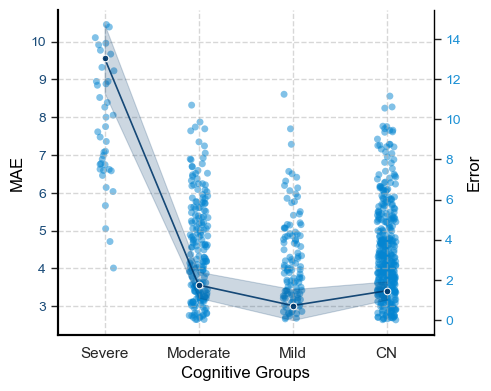

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from utils import plotting
import pandas as pd

# Example DataFrame (replace with your own data if needed)
# df = y_proba_df_all.copy()
df = y_proba_df_all.copy()

colors = [
    'xkcd:marine blue',# "#104E8B",  # dark blue
    'xkcd:cerulean'# 'xkcd:bright blue'
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

# Define bins and bin labels for the MMSE score ranges
bins = [0, 10, 20, 26, 30]
labels = ['Severe', 'Moderate', 'Mild', 'CN']
df['MMSE Groups'] = pd.cut(df['y_true'], bins=bins, labels=labels, include_lowest=True)

# Calculate the absolute error (MAE) for each data point
df['Error'] = np.absolute(df['y_pred'] - df['y_true'])

# Setup the plot with dual axes
with plotting.paper_theme():
    plt.close()
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Line plot for MAE with confidence interval
    ax1 = sns.lineplot(data=df, x='MMSE Groups', y='Error', color=colors[0], marker='o', zorder=10, ci=95)
    ax1.set_ylabel('MAE', color='black', fontsize=12)
    ax1.set_xlabel('Cognitive Groups', color='black', fontsize=12)
    # ax1.set_ylim(0, df['Error'].max() * 1.1)  # Set the MAE y-axis to start at 0
    ax1.tick_params(axis='y', labelcolor=colors[0], labelsize=10)
    ax1.tick_params(axis='x', labelsize=11)

    # Create secondary axis for absolute error jitter plot
    ax2 = ax1.twinx()
    ax2.grid(False)

    # Jitter plot for absolute errors
    sns.stripplot(x='MMSE Groups', y='Error', data=df, jitter=True, alpha=0.5, color=colors[1], ax=ax2)

    # Set label and ticks for the second y-axis (absolute error)
    ax2.set_ylabel('Error', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=colors[1], labelsize=10)
    # Line plot for mean absolute error with std on the right axis


    # Force MAE axis in front
    ax1.set_zorder(ax2.get_zorder() + 1)  # Make ax1 above ax2
    ax1.patch.set_visible(False)  # Hide the 'ax1' background to see 'ax2'

    ax2.spines[['right']].set_visible(True) # activates the right spine
    ax2.spines['right'].set_color('black') # makes sure the right spine is black
    ax2.spines['right'].set_linewidth(1.0) # makes sure the right spine is 1.0 linewidth

    # Optionally set y-limits if needed
    ax2.set_ylim(-df['Error'].max() * 0.05, df['Error'].max()*1.05)  # Increase y-axis limit for better visibility

    # Show plot
    plt.tight_layout()
    plt.savefig('./[figs]/regression_size100_jitter.pdf', dpi=600)
    plt.savefig('./[figs]/regression_size100_jitter.png', dpi=600)
    plt.show()


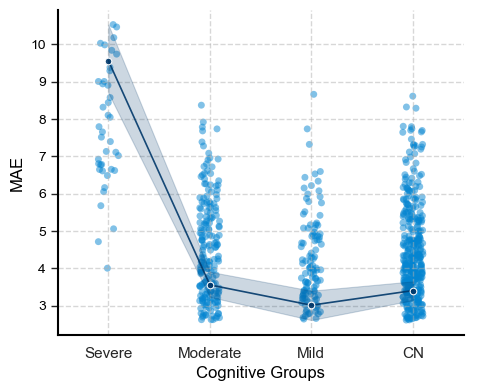

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from utils import plotting
import pandas as pd

# Example DataFrame (replace with your own data if needed)
# df = y_proba_df_all.copy()
df = y_proba_df_all.copy()

colors = [
    'xkcd:marine blue',# "#104E8B",  # dark blue
    'xkcd:cerulean'# 'xkcd:bright blue'
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

# Define bins and bin labels for the MMSE score ranges
bins = [0, 10, 20, 26, 30]
labels = ['Severe', 'Moderate', 'Mild', 'CN']
df['MMSE Groups'] = pd.cut(df['y_true'], bins=bins, labels=labels, include_lowest=True)

# Calculate the absolute error (MAE) for each data point
df['Error'] = np.absolute(df['y_pred'] - df['y_true'])

# Setup the plot with dual axes
with plotting.paper_theme():
    plt.close()
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Line plot for MAE with confidence interval
    ax1 = sns.lineplot(data=df, x='MMSE Groups', y='Error', color=colors[0], marker='o', zorder=10, ci=95)
    ax1.set_ylabel('MAE', color='black', fontsize=12)
    ax1.set_xlabel('Cognitive Groups', color='black', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='black', labelsize=10)
    ax1.tick_params(axis='x', labelsize=11)

    # Create secondary axis for absolute error jitter plot
    ax2 = ax1.twinx()
    ax2.grid(False)

    ax2.tick_params(right=False, labelright=False)
    ax2.set_ylabel('', color='white')
    
    ax2.set_yticks([])  # Remove y-axis ticks on the right
    ax2.set_yticklabels([])  # Remove y-axis tick labels on the right

    ax2.set_frame_on(False)  # Hide the ax2 frame entirely
    ax2.set_xlabel('')

    # Jitter plot for absolute errors
    sns.stripplot(x='MMSE Groups', y='Error', data=df, jitter=True, alpha=0.5, color=colors[1], ax=ax2)


    # Force MAE axis in front
    ax1.set_zorder(ax2.get_zorder() + 1)  # Make ax1 above ax2
    ax1.patch.set_visible(False)  # Hide the 'ax1' background to see 'ax2'
    # Show plot
    plt.tight_layout()
    plt.savefig('./[figs]/regression_size100_jitter.pdf', dpi=600)
    plt.savefig('./[figs]/regression_size100_jitter.png', dpi=600)

    
    plt.show()


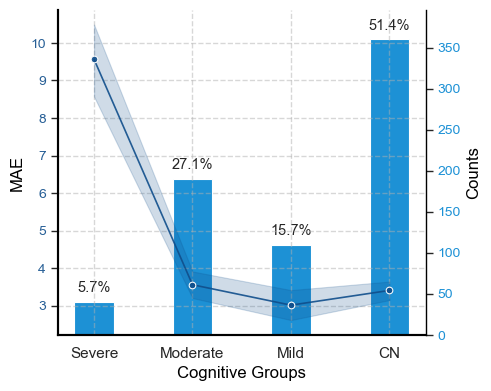

In [108]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from utils import plotting

colors = [
        # 'xkcd:bright blue',
    "#104E8B", # dark blue
    'xkcd:cerulean'
]  
colors = [mcolors.to_rgba(c, alpha=0.90) for c in colors]

df =y_proba_df_all.copy()
# Define bins and bin labels
bins = [0, 10, 20, 26, 30]
labels = ['Severe','Moderate', 'Mild', 'CN']
df['MMSE Groups'] = pd.cut(df['y_true'], bins=bins, labels=labels, include_lowest=True)

# Calculate MAE for each bin
df['Error'] = np.absolute(df['y_pred'] - df['y_true']) #((df['y_pred'] - df['y_true']) ** 2).apply(np.sqrt)
#bin_MAE = df.groupby('Binned')['Error'].mean().apply(np.sqrt)

# Calculate counts for each bin
bin_counts = df['MMSE Groups'].value_counts().sort_index()

with plotting.paper_theme():
    plt.close()
    # Setup plot with dual axes
    fig, ax1 = plt.subplots(figsize=(5, 4))


    #line, = ax1.plot(bin_MAE.index, bin_MAE.values, color=colors[0], marker='o', label='MAE', zorder=10)
    # ax1 = sns.lineplot(data=df, x='Binned', y='Error', color=colors[0], marker='o', zorder=10, ci=95)
    ax1 = sns.lineplot(data=df, x='MMSE Groups', y='Error', color=colors[0], marker='o', zorder=10, ci=95)
    ax1.set_ylabel('MAE', color='black', fontsize=12)
    ax1.set_xlabel('Cognitive Groups', color='black', fontsize=12)
    ax1.tick_params(axis='y', labelcolor=colors[0],labelsize=10)
    ax1.tick_params(axis='x',labelsize=11)

    # Create secondary axis for MAE
    ax2 = ax1.twinx()
    ax2.grid(False)

    # Bar plot for counts
    bars = ax2.bar(bin_counts.index, bin_counts.values, color=colors[1], label='Count', width=0.4, zorder=0)
    ax2.set_ylabel('Counts', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=colors[1],labelsize=10)

    # Force MAE axis in front
    ax1.set_zorder(ax2.get_zorder() + 1)  # Make ax1 above ax2
    ax1.patch.set_visible(False)  # Hide the 'ax1' background to see 'ax2'


    ax2.set_ylim(0, max(bin_counts.values) * 1.1)  # Increase y-axis limit by 10%

    percentages = [f"{(v / bin_counts.values.sum()) * 100:.1f}%" for v in bin_counts.values]
    for rect, label in zip(bars, percentages):
        height = rect.get_height()
        if label == '51.4%':  # Check if it's the problematic label
            position = height - (0.001 * height)  # Adjust position by moving it slightly down
        else:
            position = height + (0.001 * height)
        ax2.annotate(label,
                    (rect.get_x() + rect.get_width() / 2, position),
                    ha='center', va='bottom',
                    textcoords="offset points",
                    xytext=(0,5),
                    fontsize=10.5)
        
    ax1.spines[['right']].set_visible(True) # activates the right spine
    ax1.spines['right'].set_color('black') # makes sure the right spine is black
    ax1.spines['right'].set_linewidth(1.0) # makes sure the right spine is 1.0 linewidth

    #ax2.grid(True, which='major', axis='y') #### Adds gridlines for secondary axis

    plt.tight_layout()
    plt.savefig('./[figs]/regression.pdf', dpi=600)
    plt.savefig('./[figs]/regression.png', dpi=600)
    plt.show()

Display with average word rate 

Pilot dataset

In [109]:
hri_size100.head()

,pid,data,age,gender,mmse,language,mmse_split,label
0,P13,"[111, 23.42, 66.53, 87.0, 20.23, 12.33, 4.5, 9...",93,M,23,English,ad-mil,1
1,P07,"[52, 1.84, 1.0, 99.0, 79.29, 10.4, 3.85, 100.0...",95,M,15,English,ad-mod,1
2,P06,"[74, 99.0, 83.39, 3.49, 20.23, 12.33, 14.86, 8...",68,M,25,English,ad-mil,1
3,P12,"[57, 41.78, 50.51, 45.82, 20.23, 5.7, 15.79, 9...",75,F,25,English,ad-mil,1
4,P04,"[106, 62.77, 62.44, 48.58, 10.8, 15.14, 13.21,...",81,M,29,English,cn,0


In [110]:
### CHANGE feature_set = 

X_test = hri_size100['data']
y_test = hri_size100['mmse']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_regression(feature_set = 'w-liwc-size100')

# modified bootstrap function
eval, preds = ml.fit_and_evaluate_bootstrap_regression(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(eval)
df = evaluation_bootstrap_df.round(1)
df

>>>Now processing model Ridge
>>>Now processing model SVR
>>>Now processing model RFR
>>>Now processing model MLP
>>>Now processing model XGBoost


,Model,MAE Mean,MAE Lower CI,MAE Upper CI,RMSE Mean,RMSE Lower CI,RMSE Upper CI
0,Ridge,7.9,6.6,9.1,9.7,8.6,10.9
1,SVR,3.7,3.4,3.9,4.5,4.2,4.7
2,RFR,3.3,3.1,3.5,4.2,3.9,4.4
3,MLP,7.0,6.4,7.7,8.8,8.2,9.3
4,XGBoost,3.5,3.2,3.7,4.2,3.9,4.5


### Correlation cog scores

In [114]:
with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [118]:
# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in liwc_proba100 for item in sublist]
probas = np.concatenate(liwc_proba100)
df_all = pd.DataFrame(probas.round(2), columns=['prob'])
df_all['pid'] = np.tile(liwc_all_test['pid'], 10)
df_all['y_true'] = np.tile(liwc_all_test['label'], 10)
df_all

groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'mmse_split']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
merged_df_all.head()

merged_df_all[merged_df_all.pid == '54']

,pid,mmse,prob,mmse_split
65,54,28.0,0.12,cn
136,54,28.0,0.09,cn
207,54,28.0,0.30,cn
278,54,28.0,0.16,cn
349,54,28.0,0.12,cn
420,54,28.0,0.11,cn
491,54,28.0,0.04,cn
562,54,28.0,0.14,cn
633,54,28.0,0.24,cn
704,54,28.0,0.13,cn


/var/folders/xx/gc1pd92159b41vdn712h03ym0000gp/T/ipykernel_59943/1822737403.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(y * 100)}' for y in ax.get_yticks()], fontsize=10)


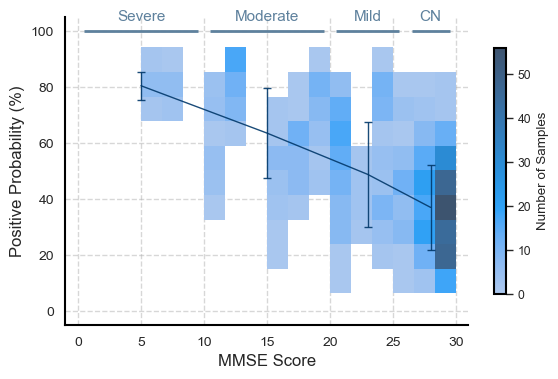

In [66]:
# hist
from utils import plotting
import seaborn as sns
import matplotlib.pyplot as plt 
# hist
with plotting.paper_theme():
    fig, ax = plt.subplots(figsize=(6.5, 4))
    sns.histplot(
        data=merged_df_all,
        y='prob',
        x='mmse',
        bins=(15, 10),
        ax=ax,
        # color='xkcd:sky blue'
        color='xkcd:powder blue'
    )

    def add_hlines(xmin, xmax, text, ax,):
        xmin = xmin + 0.5
        xmax = xmax - 0.5
        height = 1
        colour = "xkcd:greyish blue" ### choose colour name here https://xkcd.com/color/rgb/
        ax.hlines(y=height, xmin=xmin, xmax=xmax, color=colour, linestyle='-', lw=2)
        ax.text(0.5*(xmin+xmax), height+0.025, text, color=colour, fontsize=11, horizontalalignment='center', verticalalignment='bottom')

    add_hlines(0, 10, 'Severe', ax)
    add_hlines(10, 20, 'Moderate', ax)
    add_hlines(20, 26, 'Mild', ax)
    add_hlines(26, 30, 'CN', ax)


    binned_results = merged_df_all.groupby("mmse_split")[['prob', "mmse"]].agg(["mean", "std"]).swaplevel(0, 1, axis=1).sort_values(by=[("mean", "mmse")])
    line_colour = "xkcd:marine blue"
    line_alhpa = 0.9

    ax.errorbar(
        x=[5, 15, 23, 28],
        y=binned_results["mean"]["prob"],
        yerr=binned_results["std"]["prob"],
        capsize=3,
        alpha=line_alhpa,
        color=line_colour,
        linewidth=1,
    )
    ax.set_xlabel('MMSE Score', fontsize=12)
    ax.set_ylabel('Positive Probability (%)', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticklabels([f'{int(y * 100)}' for y in ax.get_yticks()], fontsize=10)
    ax.set_xticks(np.arange(0, 31, 5))
    ax.set_xlim(-1, 31)
    ax.set_xticklabels(ax.get_xticks(), fontsize=10)
    

    fig.colorbar(ax.collections[0], ax=ax, label='Number of Samples', shrink=0.8)
    plt.savefig('./[figs]/correlation_mmse.pdf', dpi=600)
    plt.savefig('./[figs]/correlation_mmse.png', dpi=600)
    plt.show()

### Risk analysis - selective classification

In [29]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict

def cross_val_predict_with_folds_UPD_UPD(model, X, y, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Generate predictions using cross_val_predict
    predictions = cross_val_predict(model, X, y, cv=skf, method='predict_proba')
    
    # For probabilities, choose the column corresponding to the positive class
    probs = predictions[:, 1]  # Assuming binary classification for simplicity
    
    # Create an array to store fold numbers
    fold_numbers = np.empty(len(y), dtype=int)
    
    # Generate fold numbers for each sample
    for fold, (_, test_index) in enumerate(skf.split(X, y)):
        fold_numbers[test_index] = fold
    
    # Create the results DataFrame
    results_df = pd.DataFrame({
        'prob': probs,
        'fold': fold_numbers,
        'y_true': y
    })
    
    return results_df


In [30]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    train_size100 = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)

groups = pd.read_csv('mapping.csv')

In [31]:
X = train_size100['data']
y = train_size100['label']
X_train_2d = np.stack(X.values)
# Normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

In [32]:
import os
import joblib
feature_abbr = 'w-liwc-size100'
model_abbr = 'rf'
filename = f"10fcv_{model_abbr}.pkl"
file_path = os.path.join("./hyperparam-tuning-UPD", feature_abbr, filename)
if os.path.exists(file_path):
    best_model = joblib.load(file_path)
best_model

RandomForestClassifier(max_depth=16, min_samples_leaf=3, min_samples_split=4,
                       n_estimators=50, random_state=42)

In [33]:
# Assuming best_model is already defined and loaded
results_df = cross_val_predict_with_folds_UPD_UPD(best_model, X_scaled_train, y)
results_df

,prob,fold,y_true
0,0.414190,3,0
1,0.268214,0,0
2,0.519063,2,0
3,0.528136,3,0
4,0.302866,2,0
...,...,...,...
161,0.596000,4,1
162,0.554976,1,1
163,0.544595,3,1
164,0.883762,4,1


In [7]:
results_df.prob.min(), results_df.prob.max()

(0.10423809523809524, 0.9435714285714286)

In [8]:
cv_probs=results_df.copy()

In [9]:
b = ml.calc_strat_stats(y, cv_probs.prob,resolution=0.1, ignore_amber=True)
b

,green,amber,sens,spec,J,roc_auc,proportion_amber
4,0.15,0.75,0.960000,1.000000,0.960000,1.000000,0.837349
9,0.25,0.75,0.923077,1.000000,0.923077,0.950000,0.783133
3,0.15,0.85,0.900000,1.000000,0.900000,1.000000,0.927711
8,0.25,0.85,0.818182,1.000000,0.818182,0.881818,0.873494
14,0.35,0.75,0.727273,1.000000,0.727273,0.874126,0.644578
15,0.35,0.65,0.790698,0.787879,0.578576,0.861170,0.542169
19,0.45,0.75,0.558140,1.000000,0.558140,0.795753,0.463855
10,0.25,0.65,0.944444,0.588235,0.532680,0.913399,0.680723
20,0.45,0.65,0.641509,0.867925,0.509434,0.799573,0.361446
13,0.35,0.85,0.500000,1.000000,0.500000,0.769231,0.734940


Filter by proportion of amber 

In [10]:
b_filter = b[b['proportion_amber'] < 0.5]
b_filter

,green,amber,sens,spec,J,roc_auc,proportion_amber
19,0.45,0.75,0.558140,1.000000,0.558140,0.795753,0.463855
20,0.45,0.65,0.641509,0.867925,0.509434,0.799573,0.361446
21,0.45,0.55,0.736111,0.754098,0.490209,0.794627,0.198795
16,0.35,0.55,0.854839,0.634146,0.488985,0.820614,0.379518


In [ ]:
b_filter = b[b['proportion_amber'] < 0.5]

In [34]:
b = ml.calc_strat_stats(y, cv_probs.prob,resolution=0.1, ignore_amber=True)
b.head(20)

,green,amber,sens,spec,J,roc_auc
2,0.15,0.95,0.000000,1.000000,0.000000,1.000000
3,0.15,0.85,0.900000,1.000000,0.900000,1.000000
4,0.15,0.75,0.960000,1.000000,0.960000,1.000000
9,0.25,0.75,0.923077,1.000000,0.923077,0.950000
10,0.25,0.65,0.944444,0.588235,0.532680,0.913399
5,0.15,0.65,0.971429,0.222222,0.193651,0.895238
0,0.05,0.65,1.000000,0.000000,0.000000,0.890756
8,0.25,0.85,0.818182,1.000000,0.818182,0.881818
14,0.35,0.75,0.727273,1.000000,0.727273,0.874126
15,0.35,0.65,0.790698,0.787879,0.578576,0.861170


In [56]:
b = ml.calc_strat_stats(y, cv_probs.prob,resolution=0.05, ignore_amber=True)
b.head(30)

,green,amber,sens,spec,J,roc_auc
14,0.15,0.75,0.960000,1.000000,0.960000,1.000000
10,0.15,0.95,0.000000,1.000000,0.000000,1.000000
11,0.15,0.90,0.666667,1.000000,0.666667,1.000000
12,0.15,0.85,0.900000,1.000000,0.900000,1.000000
13,0.15,0.80,0.947368,1.000000,0.947368,1.000000
0,0.05,0.70,1.000000,0.000000,0.000000,0.988095
5,0.10,0.70,1.000000,0.000000,0.000000,0.988095
15,0.15,0.70,0.965517,0.400000,0.365517,0.972414
24,0.20,0.75,0.923077,1.000000,0.923077,0.961538
25,0.20,0.70,0.933333,0.700000,0.633333,0.953333


In [53]:
with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [54]:
# Assuming gpt_proba is a list of 10 numpy arrays
# Assuming gpt_proba is a list of 10 numpy arrays
flat_list = [item for sublist in liwc_proba100 for item in sublist]
liwc_y_test_proba_all = np.concatenate(liwc_proba100)
y_proba_df_all = pd.DataFrame(liwc_y_test_proba_all, columns=['prob'])
y_proba_df_all['pid'] = np.tile(test_size100['pid'], 10)
y_proba_df_all['y_true'] = np.tile(test_size100['label'], 10)
y_proba_df_all

,prob,pid,y_true
0,0.243786,58,0
1,0.524262,64,1
2,0.602246,70,1
3,0.834317,71,1
4,0.249524,65,0
...,...,...,...
705,0.136381,68,0
706,0.456877,69,0
707,0.100222,55,0
708,0.431789,41,1


In [55]:
y_proba_df_all.prob.min(), y_proba_df_all.prob.max()

(0.04033333333333333, 0.9413333333333334)

In [56]:
green_thresh = 0.45
amber_thresh = 0.65

green_idx_liwc_test = y_proba_df_all[y_proba_df_all.prob < green_thresh].index.tolist()
amber_idx_liwc_test = y_proba_df_all[(y_proba_df_all.prob >= green_thresh) & (y_proba_df_all.prob < amber_thresh)].index.tolist()
red_idx_liwc_test = y_proba_df_all[y_proba_df_all.prob >= amber_thresh].index.tolist()

groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = y_proba_df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
merged_df_all.head(
)

,prob,pid,y_true,adressfname,gender,dx,age,mmse,mapping,mmse_split,age_split,merge
0,0.243786,58,0,adrso013,F,Control,70,29.0,adrsdt58,cn,70-80,58
1,0.524262,64,1,adrso038,F,ProbableAD,65,24.0,adrsdt64,ad-mil,60-69,64
2,0.602246,70,1,adrso214,M,ProbableAD,56,18.0,adrsdt70,ad-mod,50-59,70
3,0.834317,71,1,adrso083,M,ProbableAD,78,24.0,adrsdt71,ad-mil,70-80,71
4,0.249524,65,0,adrso166,F,Control,58,30.0,adrsdt65,cn,50-59,65


In [57]:
colors = ['mediumseagreen', 'khaki', 'lightcoral']

amber = merged_df_all.loc[amber_idx_liwc_test]
amber_cn = len(amber[amber.mmse_split == 'cn'])
amber_mild = len(amber[amber.mmse_split == 'ad-mil'])
amber_mod = len(amber[amber.mmse_split == 'ad-mod'])
amber_sev = len(amber[amber.mmse_split == 'ad-sev'])
print('amber')
# print(amber_cn), print(amber_mild), print(amber_mod), print(amber_sev)
print('amber proportion', (amber_cn + amber_mild + amber_mod + amber_sev) / len(merged_df_all))

green = merged_df_all.loc[green_idx_liwc_test]
green_cn = len(green[green.mmse_split == 'cn'])
green_mild = len(green[green.mmse_split == 'ad-mil'])
green_mod = len(green[green.mmse_split == 'ad-mod'])
green_sev = len(green[green.mmse_split == 'ad-sev'])
print('green')
print(green_cn), print(green_mild), print(green_mod), print(green_sev)

red = merged_df_all.loc[red_idx_liwc_test]
red_cn = len(red[red.mmse_split == 'cn'])
red_mild = len(red[red.mmse_split == 'ad-mil'])
red_mod = len(red[red.mmse_split == 'ad-mod'])
red_sev = len(red[red.mmse_split == 'ad-sev'])
print('red')
print(red_cn), print(red_mild), print(red_mod), print(red_sev)

# Calculating the totals for female and male
total_cn = green_cn + amber_cn + red_cn
total_mild = green_mild + amber_mild + red_mild
total_mod = green_mod + amber_mod + red_mod
total_sev = green_sev + amber_sev + red_sev

# green_cn, amber_cn, red_cn = 130, 197, 137
# green_mild, amber_mild, red_mild = 12, 60, 38
# green_mod, amber_mod, red_mod = 14, 59, 137
# green_sev, amber_sev, red_sev = 0, 1, 19

# Calculating the proportions
props_cn = [x / total_cn for x in [green_cn, amber_cn, red_cn]]
props_mild = [x / total_mild for x in [green_mild, amber_mild, red_mild]]
props_mod = [x / total_mod for x in [green_mod, amber_mod, red_mod]]
props_sev = [x / total_sev for x in [green_sev, amber_sev, red_sev]]

categories = ['CN', 'Mild', 'Mod', 'Sev']

amber
amber proportion 0.2887323943661972
green
250
55
27
0
red
14
29
100
20


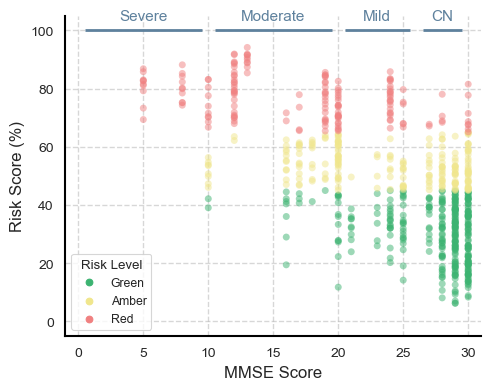

In [58]:
colors = {"Green": 'mediumseagreen', "Amber": 'khaki', "Red": 'lightcoral'}
categories = ['CN', 'Mild', 'Mod', 'Sev']

with plotting.paper_theme():
    plt.close()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax = sns.scatterplot(
        data = pd.concat(
            [
                green.assign(risk_level='Green'), 
                amber.assign(risk_level='Amber'),
                red.assign(risk_level='Red')
            ],
            axis=0
        ),
        x='mmse',
        y='prob',
        hue='risk_level',
        palette=colors,
        ax=ax,
        alpha=0.5,
        linewidth=0,
        s=25,
    )

    ax.set_ylabel('Risk Score (%)', fontsize=12)
    ax.set_xlabel('MMSE Score', fontsize=12)

    sns.move_legend(ax, "best", ncol=1, title='Risk Level')

    # Adjusting the y-axis to show percentages
    ax.set_ylim(0, 1)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)
    

    ax.set_xticks(np.arange(0, 31, 5))
    ax.set_xlim(-1, 31)
    ax.set_xticklabels(ax.get_xticks(), fontsize=10)


    def add_hlines(xmin, xmax, text, ax,):
        xmin = xmin + 0.5
        xmax = xmax - 0.5
        height = 1
        colour = "xkcd:greyish blue" ### choose colour name here https://xkcd.com/color/rgb/
        ax.hlines(y=height, xmin=xmin, xmax=xmax, color=colour, linestyle='-', lw=2)
        ax.text(0.5*(xmin+xmax), height+0.025, text, color=colour, fontsize=11, horizontalalignment='center', verticalalignment='bottom')


    add_hlines(0, 10, 'Severe', ax)
    add_hlines(10, 20, 'Moderate', ax)
    add_hlines(20, 26, 'Mild', ax)
    add_hlines(26, 30, 'CN', ax)
    ax.set_ylim(-0.05, 1.05)

    # plt.title('LR-LIWC', size=12)
    plt.tight_layout()
    # plt.savefig('./[figs]/risks_mmse_liwc_size100_055.pdf', dpi=600)
    # plt.savefig('./[figs]/risks_mmse_liwc_size100_055.png', dpi=600)
    # plt.savefig('risks_mmse_liwc.png', dpi=600)
    plt.show()

### NEW METRICS AFTER RISK - test set 

In [59]:
liwc_proba100[0]

array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
       0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
       0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
       0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
       0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
       0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
       0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
       0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
       0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
       0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
       0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
       0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
       0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
       0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
       0.85557143])

In [14]:
liwc_y_true_test = test_size100['label']

In [15]:
import utils as ut
recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(liwc_proba100, liwc_y_true_test, 0.45, 0.65)
accuracy_result = ml.calculate_metrics_with_ci(accuracies)
recall_result = ml.calculate_metrics_with_ci(recalls)
spec_result = ml.calculate_metrics_with_ci(specs)
auc_results = ml.calculate_metrics_with_ci(aucs)
print("Sensitiviy:", recall_result)
print("Specificity:", spec_result)
print("AUC:", auc_results)
print("Accuracy:", accuracy_result)

Sensitiviy: 67.6 (62.1 - 73.2)
Specificity: 96.7 (93.3 - 100.1)
AUC: 88.7 (86.2 - 91.2)
Accuracy: 83.6 (80.6 - 86.5)


In [46]:
# import utils as ut
# recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(liwc_proba100, liwc_y_true_test, 0.35, 0.55)
# accuracy_result = ml.calculate_metrics_with_ci(accuracies)
# recall_result = ml.calculate_metrics_with_ci(recalls)
# spec_result = ml.calculate_metrics_with_ci(specs)
# auc_results = ml.calculate_metrics_with_ci(aucs)
# print("Sensitiviy:", recall_result)
# print("Specificity:", spec_result)
# print("AUC:", auc_results)
# print("Accuracy:", accuracy_result)

Sensitiviy: 85.9 (80.7 - 91.0)
Specificity: 85.6 (78.1 - 93.1)
AUC: 92.3 (90.0 - 94.6)
Accuracy: 85.6 (83.1 - 88.1)


In [16]:
import utils as ut
recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(liwc_proba100, liwc_y_true_test, 0.45, 0.55)
accuracy_result = ml.calculate_metrics_with_ci(accuracies)
recall_result = ml.calculate_metrics_with_ci(recalls)
spec_result = ml.calculate_metrics_with_ci(specs)
auc_results = ml.calculate_metrics_with_ci(aucs)
print("Sensitiviy:", recall_result)
print("Specificity:", spec_result)
print("AUC:", auc_results)
print("Accuracy:", accuracy_result)

Sensitiviy: 74.4 (70.3 - 78.4)
Specificity: 90.0 (84.7 - 95.3)
AUC: 88.8 (87.0 - 90.6)
Accuracy: 82.2 (79.9 - 84.4)


#### On pilot data!!!

In [60]:
with open("./external/HRI/liwc/newLIWC22/df_liwc_all-size100.pkl", "rb") as f:
    df_hri = pickle.load(f)
df_hri.head()

with open('./external/hri/probs/liwc22-size100-probs-pilot.pkl', 'rb') as f:
    hri_liwc_proba100 = pickle.load(f)
hri_liwc_proba100 = hri_liwc_proba100['Random Forest']
hri_liwc_proba100

[array([0.87857143, 0.80797619, 0.38821429, 0.47004762, 0.31792063,
        0.54014286, 0.60430159, 0.36826984, 0.75157143, 0.62688095,
        0.4007381 , 0.59090476, 0.54071429, 0.331     , 0.62842857,
        0.49095238, 0.50977778, 0.53769841, 0.40811111, 0.30033333,
        0.44266667, 0.55003175]),
 array([0.701     , 0.64892063, 0.32971429, 0.59090476, 0.28783333,
        0.40355556, 0.59383333, 0.46365873, 0.57019048, 0.5282619 ,
        0.47783333, 0.64192063, 0.56992857, 0.45195238, 0.643     ,
        0.57271429, 0.53490476, 0.53975397, 0.33589744, 0.39680952,
        0.53471429, 0.59349206]),
 array([0.82142857, 0.79209524, 0.47166667, 0.334     , 0.48502381,
        0.66116667, 0.64673016, 0.4535    , 0.626     , 0.5545    ,
        0.64090476, 0.47559524, 0.56311905, 0.60933333, 0.67906349,
        0.63652381, 0.5725    , 0.65683333, 0.50180952, 0.40653175,
        0.60728571, 0.6745    ]),
 array([0.83916667, 0.66633333, 0.35352381, 0.24855556, 0.50904762,
        0.3536

In [61]:
with open('./external/hri/liwc/newLIWC22/df_liwc_all-size100.pkl', 'rb') as f:
    hri_size100 = pickle.load(f)

probas = np.concatenate(hri_liwc_proba100)
df_all = pd.DataFrame(probas.round(2), columns=['prob'])
df_all['pid'] = np.tile(hri_size100['pid'], 10)
df_all['y_true'] = np.tile(hri_size100['label'], 10)
df_all

,prob,pid,y_true
0,0.88,P13,1
1,0.81,P07,1
2,0.39,P06,1
3,0.47,P12,1
4,0.32,P04,0
...,...,...,...
215,0.53,P24,1
216,0.46,P20,1
217,0.45,P21,0
218,0.65,P23,0


In [43]:
df_all.pid.unique()

array(['P13', 'P07', 'P06', 'P12', 'P04', 'P10', 'P05', 'P15', 'P14',
       'P16', 'P02', 'P18', 'P08', 'P09', 'P17', 'P19', 'P25', 'P24',
       'P20', 'P21', 'P23', 'P22'], dtype=object)

In [62]:
demo = pd.read_csv('./external/HRI/demographics.csv')
demo.rename(columns=lambda x: x.lower(), inplace=True)
demo['mmse_split'] = ''
demo.loc[demo['mmse'] < 10, 'mmse_split'] = 'ad-sev'
demo.loc[(demo['mmse'] >= 10) & (demo['mmse'] <= 20), 'mmse_split'] = 'ad-mod'
demo.loc[(demo['mmse'] >= 21) & (demo['mmse'] <= 26), 'mmse_split'] = 'ad-mil'
demo.loc[demo['mmse'] > 26, 'mmse_split'] = 'cn'
demo['label'] = demo['mmse_split'].apply(lambda x: 0 if x == 'cn' else 1)
demo.head()

,pid,age,gender,mmse,language,mmse_split,label
0,P02,70,F,27,English,cn,0
1,P04,81,M,29,English,cn,0
2,P05,84,F,23,English,ad-mil,1
3,P06,68,M,25,English,ad-mil,1
4,P07,95,M,15,English,ad-mod,1


In [63]:
merged_df_all = df_all.merge(demo, left_on='pid', right_on='pid', how='left')
merged_df_all.head(
)

,prob,pid,y_true,age,gender,mmse,language,mmse_split,label
0,0.88,P13,1,93,M,23,English,ad-mil,1
1,0.81,P07,1,95,M,15,English,ad-mod,1
2,0.39,P06,1,68,M,25,English,ad-mil,1
3,0.47,P12,1,75,F,25,English,ad-mil,1
4,0.32,P04,0,81,M,29,English,cn,0


In [25]:
len(merged_df_all)

220

In [69]:
green_thresh = 0.45
amber_thresh = 0.55

green_idx_liwc_test = df_all[df_all.prob < green_thresh].index.tolist()
amber_idx_liwc_test = df_all[(df_all.prob >= green_thresh) & (df_all.prob < amber_thresh)].index.tolist()
red_idx_liwc_test = df_all[df_all.prob >= amber_thresh].index.tolist()


In [72]:
amber_idx_liwc_test

[3,
 5,
 12,
 15,
 16,
 17,
 29,
 31,
 32,
 35,
 38,
 39,
 42,
 46,
 48,
 51,
 55,
 62,
 70,
 73,
 76,
 77,
 80,
 81,
 83,
 84,
 93,
 94,
 95,
 105,
 107,
 117,
 121,
 123,
 128,
 129,
 130,
 135,
 138,
 142,
 143,
 148,
 151,
 159,
 160,
 161,
 164,
 166,
 170,
 172,
 174,
 178,
 186,
 191,
 215,
 216,
 217]

In [74]:
filtered_df = merged_df_all.loc[amber_idx_liwc_test]
filtered_df.pid.unique()

array(['P12', 'P10', 'P08', 'P19', 'P25', 'P24', 'P15', 'P16', 'P02',
       'P09', 'P23', 'P06', 'P04', 'P18', 'P20', 'P17', 'P05', 'P21'],
      dtype=object)

In [75]:
filtered_df.mmse.unique()

array([25, 26, 23, 30, 21, 28, 27, 29, 22])

In [70]:
colors = ['mediumseagreen', 'khaki', 'lightcoral']

amber = merged_df_all.loc[amber_idx_liwc_test]
amber_cn = len(amber[amber.mmse_split == 'cn'])
amber_mild = len(amber[amber.mmse_split == 'ad-mil'])
amber_mod = len(amber[amber.mmse_split == 'ad-mod'])
amber_sev = len(amber[amber.mmse_split == 'ad-sev'])
print('amber')
# print(amber_cn), print(amber_mild), print(amber_mod), print(amber_sev)
print('amber proportion', (amber_cn + amber_mild + amber_mod + amber_sev) / len(merged_df_all))

green = merged_df_all.loc[green_idx_liwc_test]
green_cn = len(green[green.mmse_split == 'cn'])
green_mild = len(green[green.mmse_split == 'ad-mil'])
green_mod = len(green[green.mmse_split == 'ad-mod'])
green_sev = len(green[green.mmse_split == 'ad-sev'])
# print(green_cn), print(green_mild), print(green_mod), print(green_sev)

red = merged_df_all.loc[red_idx_liwc_test]
red_cn = len(red[red.mmse_split == 'cn'])
red_mild = len(red[red.mmse_split == 'ad-mil'])
red_mod = len(red[red.mmse_split == 'ad-mod'])
red_sev = len(red[red.mmse_split == 'ad-sev'])
# print(red_cn), print(red_mild), print(red_mod), print(red_sev)

# Calculating the totals for female and male
total_cn = green_cn + amber_cn + red_cn
total_mild = green_mild + amber_mild + red_mild
total_mod = green_mod + amber_mod + red_mod
total_sev = green_sev + amber_sev + red_sev
print('totals')
print(total_cn), print(total_mild), print(total_mod), print(total_sev)

# # Calculating the proportions
# props_cn = [x / total_cn for x in [green_cn, amber_cn, red_cn]]
# props_mild = [x / total_mild for x in [green_mild, amber_mild, red_mild]]
# props_mod = [x / total_mod for x in [green_mod, amber_mod, red_mod]]
# props_sev = [x / total_sev for x in [green_sev, amber_sev, red_sev]]

categories = ['CN', 'Mild', 'Mod', 'Sev']

amber
amber proportion 0.2590909090909091
totals
80
120
20
0


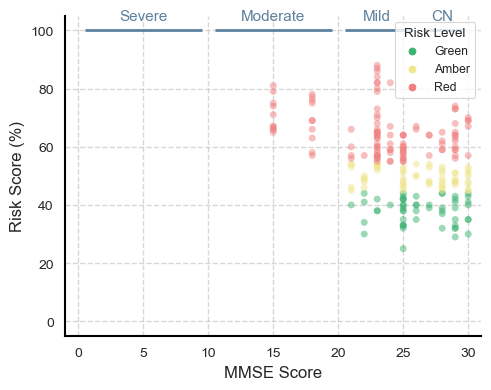

In [71]:
colors = {"Green": 'mediumseagreen', "Amber": 'khaki', "Red": 'lightcoral'}
categories = ['CN', 'Mild', 'Mod', 'Sev']

with plotting.paper_theme():
    plt.close()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax = sns.scatterplot(
        data = pd.concat(
            [
                green.assign(risk_level='Green'), 
                amber.assign(risk_level='Amber'),
                red.assign(risk_level='Red')
            ],
            axis=0
        ),
        x='mmse',
        y='prob',
        hue='risk_level',
        palette=colors,
        ax=ax,
        alpha=0.5,
        linewidth=0,
        s=25,
    )

    ax.set_ylabel('Risk Score (%)', fontsize=12)
    ax.set_xlabel('MMSE Score', fontsize=12)

    sns.move_legend(ax, "best", ncol=1, title='Risk Level')

    # Adjusting the y-axis to show percentages
    ax.set_ylim(0, 1)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(['{:.0f}'.format(y*100) for y in ax.get_yticks()], fontsize=10)
    

    ax.set_xticks(np.arange(0, 31, 5))
    ax.set_xlim(-1, 31)
    ax.set_xticklabels(ax.get_xticks(), fontsize=10)


    def add_hlines(xmin, xmax, text, ax,):
        xmin = xmin + 0.5
        xmax = xmax - 0.5
        height = 1
        colour = "xkcd:greyish blue" ### choose colour name here https://xkcd.com/color/rgb/
        ax.hlines(y=height, xmin=xmin, xmax=xmax, color=colour, linestyle='-', lw=2)
        ax.text(0.5*(xmin+xmax), height+0.025, text, color=colour, fontsize=11, horizontalalignment='center', verticalalignment='bottom')


    add_hlines(0, 10, 'Severe', ax)
    add_hlines(10, 20, 'Moderate', ax)
    add_hlines(20, 26, 'Mild', ax)
    add_hlines(26, 30, 'CN', ax)
    ax.set_ylim(-0.05, 1.05)

    # plt.title('LR-LIWC', size=12)
    plt.tight_layout()
    # plt.savefig('./[figs]/risks_mmse_liwc_size100.pdf', dpi=600)
    # plt.savefig('./[figs]/risks_mmse_liwc_size100.png', dpi=600)
    # plt.savefig('risks_mmse_liwc.png', dpi=600)
    plt.show()

In [67]:
df_all.prob.min(), df_all.prob.max()


(0.25, 0.88)

In [49]:
liwc_y_true_test = df_hri['label']

In [59]:
# import utils as ut
# recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(hri_liwc_proba100, liwc_y_true_test, 0.35, 0.55)
# accuracy_result = ml.calculate_metrics_with_ci(accuracies)
# recall_result = ml.calculate_metrics_with_ci(recalls)
# spec_result = ml.calculate_metrics_with_ci(specs)
# auc_results = ml.calculate_metrics_with_ci(aucs)
# print("Sensitiviy:", recall_result)
# print("Specificity:", spec_result)
# print("AUC:", auc_results)
# print("Accuracy:", accuracy_result)

Sensitiviy: 91.5 (85.6 - 97.4)
Specificity: 17.8 (5.1 - 30.6)
AUC: 53.1 (41.7 - 64.5)
Accuracy: 73.1 (68.0 - 78.1)


In [68]:
import utils as ut
recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(hri_liwc_proba100, liwc_y_true_test, 0.45, 0.65)
accuracy_result = ml.calculate_metrics_with_ci(accuracies)
recall_result = ml.calculate_metrics_with_ci(recalls)
spec_result = ml.calculate_metrics_with_ci(specs)
auc_results = ml.calculate_metrics_with_ci(aucs)
print("Sensitiviy:", recall_result)
print("Specificity:", spec_result)
print("AUC:", auc_results)
print("Accuracy:", accuracy_result)

Sensitiviy: 53.0 (37.4 - 68.7)
Specificity: 73.5 (55.4 - 91.6)
AUC: 67.3 (61.4 - 73.1)
Accuracy: 60.0 (51.5 - 68.5)


In [52]:
import utils as ut
recalls, specs, aucs, accuracies = ml.calc_metrics_folds_bootstrap_probabilities(hri_liwc_proba100, liwc_y_true_test, 0.45, 0.55)
accuracy_result = ml.calculate_metrics_with_ci(accuracies)
recall_result = ml.calculate_metrics_with_ci(recalls)
spec_result = ml.calculate_metrics_with_ci(specs)
auc_results = ml.calculate_metrics_with_ci(aucs)
print("Sensitiviy:", recall_result)
print("Specificity:", spec_result)
print("AUC:", auc_results)
print("Accuracy:", accuracy_result)

Sensitiviy: 72.2 (60.3 - 84.1)
Specificity: 49.3 (33.0 - 65.6)
AUC: 61.1 (55.0 - 67.2)
Accuracy: 64.9 (57.9 - 72.0)


### Group splits - demographic

In [34]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)
y_test = test_size100['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

In [35]:
y_test

0     0
1     1
2     1
3     1
4     0
     ..
66    0
67    0
68    0
69    1
70    1
Name: label, Length: 71, dtype: int64

In [36]:
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [15]:
groups.head()

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80


In [13]:
test_size100.head()

,pid,label,data
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89...."
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9..."
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95..."
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97...."
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15..."


In [37]:
df = test_size100.merge(groups, left_on='pid', right_on='pid', how='left')
df['gender'] = df['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
df.head()

,pid,label,data,adressfname,gender,dx,age,mmse,mmse_split,age_split
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",adrso013,F,Control,70,29.0,cn,70-80
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",adrso038,F,ProbableAD,65,24.0,ad-mil,60-69
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",adrso214,M,ProbableAD,56,18.0,ad-mod,50-59
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",adrso083,M,ProbableAD,78,24.0,ad-mil,70-80
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",adrso166,F,Control,58,30.0,cn,50-59


In [38]:
df.data[0].shape

(100,)

In [18]:
liwc_groups = df.copy()
male_idx = liwc_groups[liwc_groups['gender'] == 'M'].index.tolist()
female_idx = liwc_groups[liwc_groups['gender'] == 'F'].index.tolist()
print(len(male_idx))
print(len(female_idx))

27
44


In [6]:
fem_1 = liwc_groups[(liwc_groups['gender'] == 'F') & (liwc_groups['label'] == 1)].shape[0]
fem_0 = liwc_groups[(liwc_groups['gender'] == 'F') & (liwc_groups['label'] == 0)].shape[0]
male_1 = liwc_groups[(liwc_groups['gender'] == 'M') & (liwc_groups['label'] == 1)].shape[0]
male_0 = liwc_groups[(liwc_groups['gender'] == 'M') & (liwc_groups['label'] == 0)].shape[0]
round(fem_0/fem_1, 1), round(male_0/male_1, 1)

(1.1, 0.9)

In [7]:
def groups(y_test, proba, idx):
    mean_acc, lower_ci, upper_ci, mean_lik, lower_lik, upper_lik = ml.splits_performace(y_test, proba, idx)
    acc_str = f"Mean Accuracy: {mean_acc} ({lower_ci} - {upper_ci})"
    lik_str = f"Mean Likelihood of positive: {mean_lik} ({lower_lik} - {upper_lik})"
    return acc_str, lik_str

In [7]:
print('Female')
groups(y_test, liwc_proba100, female_idx)

Female


('Mean Accuracy: 76.4 (74.6 - 78.1)',
 'Mean Likelihood of positive: 42.3 (38.6 - 46.0)')

In [8]:
print('Male')
groups(y_test, liwc_proba100, male_idx)

Male


('Mean Accuracy: 76.7 (72.2 - 81.2)',
 'Mean Likelihood of positive: 43.3 (37.9 - 48.8)')

Age

In [8]:
age_1_idx = df[df.age_split == '50-59'].index.tolist()
age_2_idx = df[df.age_split == '60-69'].index.tolist()
age_3_idx = df[df.age_split == '70-80'].index.tolist()
len(age_1_idx), len(age_2_idx), len(age_3_idx)

age_1_1 = liwc_groups[(liwc_groups.age_split == '50-59') & (liwc_groups.label == 1)].shape[0]
age_1_0 = liwc_groups[(liwc_groups.age_split == '50-59') & (liwc_groups.label == 0)].shape[0]
age_2_1 = liwc_groups[(liwc_groups.age_split == '60-69') & (liwc_groups.label == 1)].shape[0]
age_2_0 = liwc_groups[(liwc_groups.age_split == '60-69') & (liwc_groups.label == 0)].shape[0]
age_3_1 = liwc_groups[(liwc_groups.age_split == '70-80') & (liwc_groups.label == 1)].shape[0]
age_3_0 = liwc_groups[(liwc_groups.age_split == '70-80') & (liwc_groups.label == 0)].shape[0]

round(age_1_0/age_1_1, 1), round(age_2_0/age_2_1, 1), round(age_3_0/age_3_1, 1)

(1.3, 1.2, 0.8)

In [10]:
print('Age 50-59')
groups(y_test, liwc_proba100, age_1_idx)

Age 50-59


('Mean Accuracy: 83.6 (78.2 - 89.0)',
 'Mean Likelihood of positive: 42.1 (34.7 - 49.5)')

In [11]:
print('Age 60-69')
groups(y_test, liwc_proba100, age_2_idx)

Age 60-69


('Mean Accuracy: 75.9 (72.6 - 79.3)',
 'Mean Likelihood of positive: 37.4 (31.5 - 43.3)')

In [12]:
print('Age 70-80')
groups(y_test, liwc_proba100, age_3_idx)

Age 70-80


('Mean Accuracy: 73.7 (71.0 - 76.3)',
 'Mean Likelihood of positive: 47.7 (44.7 - 50.7)')

### Group splits - MMSE

In [19]:
df.head()

,pid,label,data,adressfname,gender,dx,age,mmse,mmse_split,age_split
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89....",adrso013,F,Control,70,29.0,cn,70-80
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9...",adrso038,F,ProbableAD,65,24.0,ad-mil,60-69
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95...",adrso214,M,ProbableAD,56,18.0,ad-mod,50-59
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97....",adrso083,M,ProbableAD,78,24.0,ad-mil,70-80
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15...",adrso166,F,Control,58,30.0,cn,50-59


In [20]:
mmse_1_idx = df[df.mmse_split == 'cn'].index.tolist()
mmse_2_idx = df[df.mmse_split == 'ad-mil'].index.tolist()
mmse_3_idx = df[df.mmse_split == 'ad-mod'].index.tolist()
mmse_4_idx = df[df.mmse_split == 'ad-sev'].index.tolist()
len(mmse_1_idx), len(mmse_2_idx), len(mmse_3_idx), len(mmse_4_idx)

(36, 11, 21, 2)

In [28]:
mmse_1_1 = liwc_groups[(liwc_groups.mmse_split == 'cn') & (liwc_groups.label == 1)].shape[0]
mmse_1_0 = liwc_groups[(liwc_groups.mmse_split == 'cn') & (liwc_groups.label == 0)].shape[0]
mmse_2_1 = liwc_groups[(liwc_groups.mmse_split == 'ad-mil') & (liwc_groups.label == 1)].shape[0]
mmse_2_0 = liwc_groups[(liwc_groups.mmse_split == 'ad-mil') & (liwc_groups.label == 0)].shape[0]
mmse_3_1 = liwc_groups[(liwc_groups.mmse_split == 'ad-mod') & (liwc_groups.label == 1)].shape[0]
mmse_3_0 = liwc_groups[(liwc_groups.mmse_split == 'ad-mod') & (liwc_groups.label == 0)].shape[0]
mmse_4_1 = liwc_groups[(liwc_groups.mmse_split == 'ad-sev') & (liwc_groups.label == 1)].shape[0]
mmse_4_0 = liwc_groups[(liwc_groups.mmse_split == 'ad-sev') & (liwc_groups.label == 0)].shape[0]
round(mmse_1_0/mmse_1_1, 1), round(mmse_2_0/mmse_2_1, 1), round(mmse_3_0/mmse_3_1, 1), round(mmse_4_0/mmse_4_1, 1)

(17.0, 0.1, 0.0, 0.0)

In [23]:
def groups(y_test, proba, idx):
    mean_acc, lower_ci, upper_ci, mean_lik, lower_lik, upper_lik = ml.splits_performace(y_test, proba, idx)
    acc_str = f"Mean Accuracy: {mean_acc} ({lower_ci} - {upper_ci})"
    lik_str = f"Mean Likelihood of positive: {mean_lik} ({lower_lik} - {upper_lik})"
    return acc_str, lik_str

In [24]:
print('CN')
groups(y_test, liwc_proba100, mmse_1_idx)

CN


('Mean Accuracy: 81.9 (76.8 - 87.1)',
 'Mean Likelihood of positive: 20.8 (15.0 - 26.6)')

In [25]:
print('Mild')
groups(y_test, liwc_proba100, mmse_2_idx)

Mild


('Mean Accuracy: 48.2 (43.8 - 52.6)',
 'Mean Likelihood of positive: 39.1 (34.7 - 43.5)')

In [26]:
print('Moderate')
groups(y_test, liwc_proba100, mmse_3_idx)

Moderate


('Mean Accuracy: 78.6 (73.7 - 83.5)',
 'Mean Likelihood of positive: 78.6 (73.7 - 83.5)')

In [27]:
print('Severe')
groups(y_test, liwc_proba100, mmse_4_idx)

Severe


('Mean Accuracy: 100.0 (100.0 - 100.0)',
 'Mean Likelihood of positive: 100.0 (100.0 - 100.0)')

### Calibration

In [170]:
with open('./FEATURES/dfs/liwc22-size100.pkl', 'rb') as f:
    train_size100 = pickle.load(f)

with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)

with open('./external/lu/liwc/liwc22-size100-raw.pkl', 'rb') as f:
    ext_size100 = pickle.load(f)

with open('./external/hri/liwc/newLIWC22/df_liwc_all-size100.pkl', 'rb') as f:
    hri_size100 = pickle.load(f)

groups = pd.read_csv('mapping.csv')


with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

In [135]:
test_size100.head()

,pid,label,data
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89...."
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9..."
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95..."
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97...."
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15..."


In [174]:
groups.head()

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80


In [177]:
def probs_mmse(probs, groups):

    probability_values = [
        np.array(
            p[np.arange(len(p))] 
        ) for p in probs
        ]

    mmse_values = groups.mmse.values
    pid_values = groups.astype({'pid': int}).pid.values
    
    results = []
    for run, probs in enumerate(probability_values):
        results.append(
            pd.DataFrame(
                {   
                    'pid': pid_values,
                    'mmse': mmse_values,
                    'probs': probs,
                    'run': run
                }
            )
        )
    results = pd.concat(results)
    results = results.dropna(subset=['mmse'])
    results.mmse = results.mmse.astype(int)
    return results

df = probs_mmse(liwc_proba100, groups)
df.head()

,pid,mmse,probs,run
0,15,30,0.243786,0
1,40,28,0.524262,0
2,26,29,0.602246,0
3,67,30,0.834317,0
4,58,29,0.249524,0


In [182]:
with open('./FEATURES/test-features/dfs/liwc22-size100.pkl', 'rb') as f:
    test_size100 = pickle.load(f)
y_test = test_size100['label']

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

with open('./evaluation-test-UPD/liwc22-size100-probs.pkl', 'rb') as f:
    liwc_proba100 = pickle.load(f)
liwc_proba100 = liwc_proba100['Random Forest']

results=[]
# Iterate over the probabilities and runs
for run, probs in enumerate(liwc_proba100):
    # Create a DataFrame for each run
    run_df = pd.DataFrame({
        'pid': test_size100['pid'],
        'prob': probs.round(2),
        'y_true': test_size100['label'],
        'run': run
    })
    
    # Append the DataFrame to the results list
    results.append(run_df)

# Concatenate all the results into a single DataFrame
df_all = pd.concat(results).reset_index(drop=True)
df_all.head()

# # Assuming gpt_proba is a list of 10 numpy arrays
# flat_list = [item for sublist in liwc_proba100 for item in sublist]
# probas = np.concatenate(liwc_proba100)
# df_all = pd.DataFrame(probas.round(2), columns=['prob'])
# df_all['pid'] = np.tile(test_size100['pid'], 10)
# df_all['y_true'] = np.tile(test_size100['label'], 10)




,pid,prob,y_true,run
0,58,0.24,0,0
1,64,0.52,1,0
2,70,0.60,1,0
3,71,0.83,1,0
4,65,0.25,0,0


In [184]:
groups = pd.read_csv('mapping.csv')
groups['merge'] = groups['mapping'].str.extract(r'dt(\d+)')
merged_df_all = df_all.merge(groups, left_on='pid', right_on='merge', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split', 'age_split', 'run']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
# y_test
y_test_boots = merged_df_all.y_true
merged_df_all.head()

,pid,mmse,prob,y_true,mmse_split,age_split,run
0,58,29.0,0.24,0,cn,70-80,0
1,64,24.0,0.52,1,ad-mil,60-69,0
2,70,18.0,0.60,1,ad-mod,50-59,0
3,71,24.0,0.83,1,ad-mil,70-80,0
4,65,30.0,0.25,0,cn,50-59,0


In [188]:
merged_df_all.run.nunique()

10

In [185]:
liwc_proba100

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [156]:
probs_avg = np.mean(liwc_proba100, axis=0)
probs_avg

array([0.38438201, 0.66431494, 0.54944841, 0.73943266, 0.20964133,
       0.39797566, 0.50326861, 0.27563816, 0.56111984, 0.6405381 ,
       0.41701551, 0.58641276, 0.57279877, 0.21536688, 0.72637625,
       0.74543254, 0.62852381, 0.19580267, 0.30396739, 0.36811508,
       0.25296061, 0.85824285, 0.51810662, 0.80539358, 0.7778381 ,
       0.43890556, 0.49329683, 0.52418175, 0.32822222, 0.64842698,
       0.65366429, 0.21631508, 0.59714206, 0.40468622, 0.33566032,
       0.61979127, 0.37989921, 0.33230714, 0.39390123, 0.34108889,
       0.43595159, 0.53822705, 0.33691111, 0.90031263, 0.24764524,
       0.27768362, 0.39667381, 0.4448381 , 0.4504    , 0.33309921,
       0.71486667, 0.53500952, 0.21845952, 0.41723139, 0.8030619 ,
       0.35421299, 0.34774646, 0.74529762, 0.46648528, 0.78752424,
       0.4503759 , 0.43037547, 0.42218492, 0.58673413, 0.24955967,
       0.14303889, 0.2224254 , 0.53624639, 0.12613492, 0.48208766,
       0.75791508])

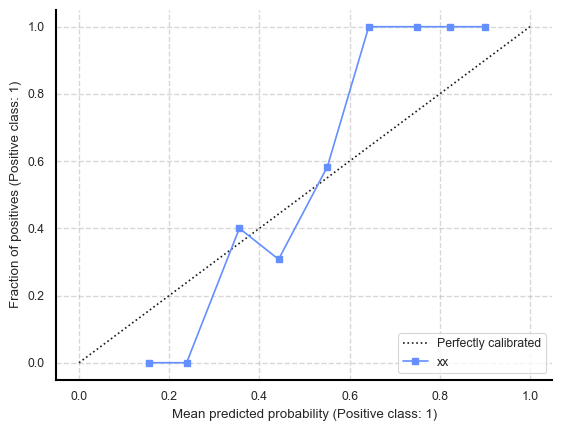

In [168]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
with plotting.paper_theme():
    CalibrationDisplay.from_predictions(y_test, probs_avg, n_bins=10, name='xx')
    plt.show()

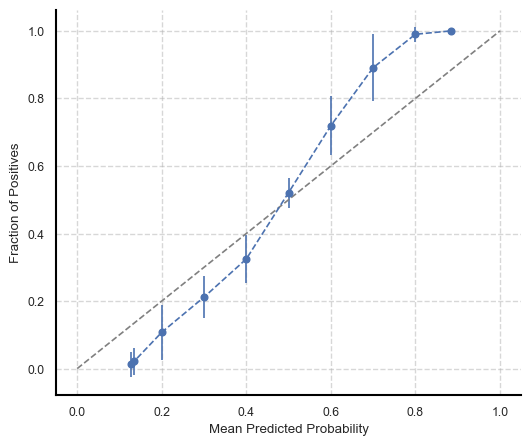

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

# Initialize lists to store mean predicted probabilities and fraction of positives per run
mean_pred_prob_list = []
fraction_of_positives_list = []
n_bins = 10

# Create fixed bin edges to ensure consistent binning across all runs
bin_edges = np.linspace(0, 1, n_bins + 1)

# Group by 'run' column to calculate calibration curves for each run
for run, group in merged_df_all.groupby('run'):
    # Get the true labels and predicted probabilities for each run
    y_true_run = group['y_true']
    y_prob_run = group['prob']
    
    # Calculate the calibration curve using the pre-defined bin edges
    prob_true, prob_pred = calibration_curve(y_true_run, y_prob_run, n_bins=n_bins, strategy='uniform')
    
    # Interpolate prob_true and prob_pred to match the fixed bin edges
    prob_pred_interp = np.interp(bin_edges[:-1], prob_pred, prob_pred)
    prob_true_interp = np.interp(bin_edges[:-1], prob_pred, prob_true)
    
    # Append the interpolated results
    mean_pred_prob_list.append(prob_pred_interp)
    fraction_of_positives_list.append(prob_true_interp)

# Convert lists to arrays for easier calculation of mean and std
mean_pred_prob_array = np.array(mean_pred_prob_list)
fraction_of_positives_array = np.array(fraction_of_positives_list)

# Calculate means and standard deviations across runs
mean_pred_prob_mean = np.mean(mean_pred_prob_array, axis=0)
fraction_of_positives_mean = np.mean(fraction_of_positives_array, axis=0)
fraction_of_positives_std = np.std(fraction_of_positives_array, axis=0)

with plotting.paper_theme():
    # Plot the calibration curve with error bars (representing the std deviation across runs)
    plt.figure(figsize=(6, 5))
    plt.errorbar(mean_pred_prob_mean, fraction_of_positives_mean, yerr=fraction_of_positives_std, fmt='o', linestyle='--', color='b', label='Calibration with Runs')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')

    # Show the plot
    plt.show()


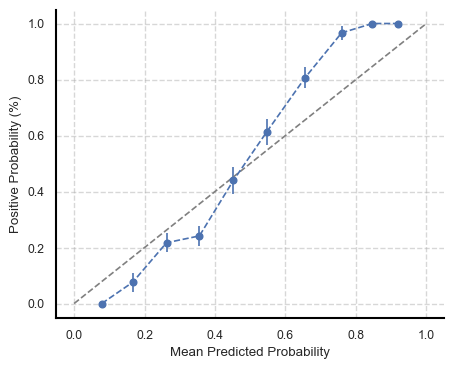

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

y_true = merged_df_all['y_true']
y_prob = merged_df_all['prob']

mean_pred_prob_list = []
fraction_of_positives_list = []
std_dev_list = []

n_bootstraps = 10
n_bins = 10

# Bootstrap sampling
for i in range(n_bootstraps):
    # Resample the data (with replacement)
    df_resampled = resample(merged_df_all, n_samples=len(merged_df_all), random_state=i)
    
    y_true_resampled = df_resampled['y_true']
    y_prob_resampled = df_resampled['prob']
    
    prob_true, prob_pred = calibration_curve(y_true_resampled, y_prob_resampled, n_bins=n_bins)
    
    # Append results
    mean_pred_prob_list.append(prob_pred)
    fraction_of_positives_list.append(prob_true)

mean_pred_prob_array = np.array(mean_pred_prob_list)
fraction_of_positives_array = np.array(fraction_of_positives_list)

# Calculate means and standard deviations across bootstraps
mean_pred_prob_mean = np.mean(mean_pred_prob_array, axis=0)
fraction_of_positives_mean = np.mean(fraction_of_positives_array, axis=0)
fraction_of_positives_std = np.std(fraction_of_positives_array, axis=0)
with plotting.paper_theme():
    # Plot the calibration curve with error bars
    plt.figure(figsize=(5, 4))
    plt.errorbar(mean_pred_prob_mean, fraction_of_positives_mean, yerr=fraction_of_positives_std, fmt='o', linestyle='--', color='b')

    # Add a reference line for perfect calibration
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

    # Add labels and title
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Positive Probability (%)')
    plt.show()